# Personal Information
Name: **Jia Long Bao**

StudentID: **12593400**

Email: [**jialong.bao@student.uva.nl**](jialong.bao@student.uva.nl)

Submitted on: **XX.10.2025**

# Data Context
**In this section you should introduce the datasources and datasets which you will be working with. Explain where they are from as well as their domain. Give an overview of what the context of the data is. You should not spend more than 1 to 2 paragraphs here as the core information will be in the next section.**

The data used in this research originates from Rijden De Treinen, capturing spatial, temporal, and reported causes that influence train delays in the Netherlands. The data contains all train services from the beginning of 2019 till 2025. Each row represent a stop at a station. Furthermore, each service at least departs and arrives at a station, which means there are two rows. 

The spatial data, which includes (station locations and) railway connections, is extracted from Rijden de Treinen, a platform that processes real-time open data from NDOV (Nationale Data Openbaar Vervoer) and extracts data through the NS API. This ensures an accurate representation of the railway network, which forms the foundation of modeling the graph structure. 

The temporal data consists of train service schedules, recorded delays and disruptions all sourced from Rijden de Treinen.

Additionally we complement this dataset with a dutch national holiday dataset and per station weather hourly dataset.

Github: https://github.com/jbaonl/MSc-Thesis

# Data Description

**Present here the results of your exploratory data analysis. Note that there is no need to have a "story line" - it is more important that you show your understanding of the data and the methods that you will be using in your experiments (i.e. your methodology).**

**As an example, you could show data, label, or group balances, skewness, and basic characterizations of the data. Information about data frequency and distributions as well as results from reduction mechanisms such as PCA could be useful. Furthermore, indicate outliers and how/why you are taking them out of your samples, if you do so.**

**The idea is, that you conduct this analysis to a) understand the data better but b) also to verify the shapes of the distributions and whether they meet the assumptions of the methods that you will attempt to use. Finally, make good use of images, diagrams, and tables to showcase what information you have extracted from your data.**

As you can see, you are in a jupyter notebook environment here. This means that you should focus little on writing text and more on actually exploring your data. If you need to, you can use the amsmath environment in-line: $e=mc^2$ or also in separate equations such as here:

\begin{equation}
    e=mc^2 \mathrm{\space where \space} e,m,c\in \mathbb{R}
\end{equation}

Furthermore, you can insert images such as your data aggregation diagrams like this:

![image](example.png)

In [2]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import networkx as nx
import re
import duckdb
from pathlib import Path

### Data Loading

In [3]:
from pathlib import Path
root_folder =  Path("downloads/data/raw/")
filtered_output_root_folder = Path("downloads/data/filtered/")

services_path = root_folder / "NS-services/services_merged_all_ns_only.parquet"
disruptions_path = root_folder / "NS-disruptions/disruptions_merged_all.parquet"
stations_path = root_folder / "NS-stations/stations-2023-09-nl.csv"
station_distances_path = root_folder / "NS-tariff-distances/tariff-distances-2022-01.csv" #probably not used

weather_path = root_folder / "weather/weather_merged_all.parquet"
holiday_path = root_folder / "holidays/dutch_holidays_2019_2025.parquet"

# 1. Setup paths to iterate over

paths = {
    "Services": services_path,
    "Disruptions": disruptions_path,
    "Stations": stations_path,
    "Station Distances": station_distances_path,
    "Weather": weather_path,
    "Holidays": holiday_path
}


#### Duckdb prep

In [19]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# 2. Initialize Disk-Based Database
# This creates a file 'ns_data.duckdb' in your current folder.
# Intermediate calculations (joins/group bys) will spill here instead of crashing RAM.
con = duckdb.connect(database='ns_data.duckdb') 

# 3. Register Views (Zero-Copy)
# We use VIEWs so we don't duplicate the Parquet data into the .duckdb file.
# DuckDB reads directly from the parquet files on demand.
con.execute(f"CREATE OR REPLACE VIEW raw_services AS SELECT * FROM read_parquet('{services_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_disruptions AS SELECT * FROM read_parquet('{disruptions_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_weather AS SELECT * FROM read_parquet('{weather_path}')")
con.execute(f"CREATE OR REPLACE TABLE stations AS SELECT * FROM read_csv_auto('{stations_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_holidays AS SELECT * FROM read_parquet('{holiday_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_station_distances AS SELECT * FROM read_csv_auto('{station_distances_path}')")

# 4. Create CLEAN Views (Logic remains the same, but executed safely)
con.execute("""
    CREATE OR REPLACE VIEW services AS 
    SELECT 
        "Service:RDT-ID" AS service_id,
        "Service:Date" AS service_date,
        "Service:Type" AS train_type,
        "Stop:Station code" AS station_code,
        "Stop:Station name" AS station_name,
        "Stop:Arrival time" AS arrival_time,
        "Stop:Arrival delay" / 60.0 AS arrival_delay_min,
        "Stop:Arrival cancelled" AS is_cancelled,
        "Stop:Departure time" AS departure_time
    FROM raw_services
""")

con.execute("""
    CREATE OR REPLACE VIEW disruptions AS 
    SELECT 
        *,
        CASE 
            WHEN rdt_station_codes LIKE '[%]' 
            THEN string_split(trim(rdt_station_codes, '[]'), ', ') 
            ELSE string_split(rdt_station_codes, ',') 
        END AS station_array
    FROM raw_disruptions
""")

print("Disk-based database initialized. Queries will now spill to 'ns_data.duckdb' if needed.")

Disk-based database initialized. Queries will now spill to 'ns_data.duckdb' if needed.


In [ ]:

# import duckdb

# # Example 1: just peek at the data
# # .show() prints it nicely to the console
# duckdb.sql(f"SELECT * FROM '{services_path}' LIMIT 5").show()

# # Example 2: Run a heavy aggregation
# # This runs in milliseconds because it uses all CPU cores
# query = f"""
#     SELECT 
#         station_name, 
#         AVG(temperature_2m) as avg_temp,
#         MAX(wind_speed_10m) as max_wind
#     FROM '{services_path}'
#     GROUP BY station_name
#     ORDER BY avg_temp DESC
#     LIMIT 10
# """

# # .df() converts the RESULT (not the whole file) to a Pandas DataFrame
# top_hot_stations = duckdb.sql(query).df()
# print(top_hot_stations)

# # This shows Column Name, Column Type, Nullable, etc.
# duckdb.sql(f"DESCRIBE SELECT * FROM '{services_path}'").show()
# # This gives you stats per column, including missing values (null_percentage)
# duckdb.sql(f"SUMMARIZE SELECT * FROM '{services_path}'").show()

┌────────────────┬───────┬──────────┬────────────┬────────────────┬────────────────┬───────────────────────────┬────────┬──────────────────────────┬──────────────┬───────────────────┬─────────────────┬─────────────────┬──────────────────────────┬───────────────────────────────────────────┐
│ temperature_2m │ rain  │ snowfall │ snow_depth │ wind_speed_10m │ wind_gusts_10m │ soil_temperature_0_to_7cm │ rdt_id │           time           │ station_code │   station_name    │    latitude     │    longitude    │           date           │                 filename                  │
│     float      │ float │  float   │   float    │     float      │     float      │           float           │ int64  │ timestamp with time zone │   varchar    │      varchar      │     double      │     double      │ timestamp with time zone │                  varchar                  │
├────────────────┼───────┼──────────┼────────────┼────────────────┼────────────────┼───────────────────────────┼────────┼──────

In [4]:
# This shows Column Name, Column Type, Nullable, etc.
duckdb.sql(f"DESCRIBE SELECT * FROM '{services_path}'").show()
# This gives you stats per column, including missing values (null_percentage)
duckdb.sql(f"SUMMARIZE SELECT * FROM '{services_path}'").show()


┌──────────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │       column_type        │  null   │   key   │ default │  extra  │
│           varchar            │         varchar          │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE                     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN                  │ YES     │ NULL    │ NULL    │ NULL    │


In [ ]:
# # This gives you stats per column, including missing values (null_percentage)
# md_output = duckdb.sql(f"DESCRIBE SELECT * FROM '{holiday_path}'").df().to_markdown()
# duckdb.sql(f"SUMMARIZE SELECT * FROM '{holiday_path}'")

# print(md_output)

|    | column_name   | column_type   | null   | key   | default   | extra   |
|---:|:--------------|:--------------|:-------|:------|:----------|:--------|
|  0 | date          | TIMESTAMP_NS  | YES    |       |           |         |
|  1 | holiday_name  | VARCHAR       | YES    |       |           |         |
|  2 | year          | INTEGER       | YES    |       |           |         |
|  3 | day_of_week   | VARCHAR       | YES    |       |           |         |


### All datasets Data types and null values 

The null values in the Services dataset for the arrival and departure columns means that no departure or no arrival was planned (source: https://www.rijdendetreinen.nl/open-data/treinarchief )


In [23]:
# This shows Column Name, Column Type, Nullable, etc.
duckdb.sql(f"DESCRIBE SELECT * FROM '{services_path}'").show()
# This gives you stats per column, including missing values (null_percentage)
duckdb.sql(f"SUMMARIZE SELECT * FROM '{services_path}'").show()


┌──────────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │       column_type        │  null   │   key   │ default │  extra  │
│           varchar            │         varchar          │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE                     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN                  │ YES     │ NULL    │ NULL    │ NULL    │


Some ns_lines seem to not be preprocessed correctly by rdt as the rdt_ columns are processed from ns_lines column

Furthermore some endtimes seem to be missing (probably along with their respective duration)

It is noted that the cause_nl only captures the last cause 

In [24]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{disruptions_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{disruptions_path}'").show()

┌──────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │ column_type │  null   │   key   │ default │  extra  │
│       varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ rdt_id               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ ns_lines             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_lines            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_lines_id         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_station_names    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_station_codes    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ cause_nl             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ cause_en             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ statistical_cause_nl │ VARCHAR     │ YES     │ NUL

Stations dataset has no missing values complete (-> initially stations_df when utilizing pandas read_csv in the download_data.ipynb notebook had 1 missing value, but that is fixed now and does not seem to be the case with duckdb)

The official Type column description: 
The category of the station. Possible values are (from major to minor station): megastation, knooppuntIntercitystation, intercitystation, knooppuntSneltreinstation, sneltreinstation, knooppuntStoptreinstation, stoptreinstation, facultatiefStation. The category knooppunt (junction) implies that these stations are meant for changing trains. A facultatiefStation is a station which is not regularly served by trains, except for special events (e.g. soccer matches).



In [25]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{stations_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{stations_path}'").show()

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ code        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ uic         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ name_short  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_medium │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_long   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ slug        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ country     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ type        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lat     │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lng     │ DOUB

400 railway stations in the netherlands (station distances 'column_name' = station 'code')
Shortest route between each station for NS train operations (in other words it does NOT represent the connections for each station that we could utilize to construct the graph, however the distances between stations might potentially be interesting as edge weight features of the constructed railnetwork graph)

The following conventions are used in the dataset:

Number: the distance between two stations.
? (question mark): there is no route available between the two stations.
XXX: the two stations are the same station.


In [26]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{station_distances_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{station_distances_path}'").show()

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AC          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AH          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AHP         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AHPR        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AHZ         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AKL         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AKM         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ALM         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ALMB        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│  ·          │    ·

Weather data was retrieved using the stations dataset, no missing values

We can merge the weather 'station_code' with services 'Stop:Station code'

In [5]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{weather_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{weather_path}'").show()

┌───────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│        column_name        │       column_type        │  null   │   key   │ default │  extra  │
│          varchar          │         varchar          │ varchar │ varchar │ varchar │ varchar │
├───────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ date                      │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ temperature_2m            │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ rain                      │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ snowfall                  │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ snow_depth                │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ wind_speed_10m            │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ wind_gusts_10m            │ 

Holidays dataset, no missing values

In [30]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{holiday_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{holiday_path}'").show()

┌──────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │ column_type  │  null   │   key   │ default │  extra  │
│   varchar    │   varchar    │ varchar │ varchar │ varchar │ varchar │
├──────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ date         │ TIMESTAMP_NS │ YES     │ NULL    │ NULL    │ NULL    │
│ holiday_name │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ year         │ INTEGER      │ YES     │ NULL    │ NULL    │ NULL    │
│ day_of_week  │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
└──────────────┴──────────────┴─────────┴─────────┴─────────┴─────────┘

┌──────────────┬──────────────┬─────────────────────┬─────────────────────┬───────────────┬─────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬───────┬─────────────────┐
│ column_name  │ column_type  │         min         │         max         │ approx_unique │         avg         │        std

## Services Dataset

### Missing days check

In [13]:
# --- Cell: Data Integrity Check (Missing Days) ---

print("Checking for missing dates in the timeline...")

# 1. SQL to find missing days
# We generate a full sequence of days from MIN to MAX, then find which ones don't exist in 'services'.
gap_query = """
    WITH range AS (
        -- 1. Get the start and end of the dataset
        SELECT MIN(service_date) as start_date, MAX(service_date) as end_date
        FROM services
    ),
    full_calendar AS (
        -- 2. Generate every single day between start and end
        SELECT CAST(unnest(generate_series(start_date, end_date, INTERVAL 1 DAY)) AS DATE) as calendar_day
        FROM range
    ),
    actual_days AS (
        -- 3. Get the days we actually have data for
        SELECT DISTINCT service_date 
        FROM services
    )
    -- 4. Find days in calendar that are NOT in actual_days
    SELECT calendar_day as missing_date
    FROM full_calendar
    LEFT JOIN actual_days ON full_calendar.calendar_day = actual_days.service_date
    WHERE actual_days.service_date IS NULL
    ORDER BY 1
"""

df_gaps = con.execute(gap_query).df()

# 2. Report Results
total_days = con.execute("SELECT COUNT(DISTINCT service_date) FROM services").fetchone()[0]
missing_count = len(df_gaps)

print(f"Total active days in dataset: {total_days}")
print(f"Total missing days (gaps):    {missing_count}")

if missing_count > 0:
    print("\n⚠️ WARNING: The following dates have ZERO service records:")
    # Print first 20 to avoid spamming if there's a huge gap
    print(df_gaps.head(20))
    
    # Optional: Visualizing the gap
    plt.figure(figsize=(12, 2))
    plt.scatter(df_gaps['missing_date'], [1]*missing_count, color='red', marker='x', s=100, label='Missing Data')
    plt.yticks([])
    plt.title("Timeline of Missing Data")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Success: The dataset is continuous. No missing days found.")

Checking for missing dates in the timeline...
Total active days in dataset: 2192
Total missing days (gaps):    0

✅ Success: The dataset is continuous. No missing days found.


### Missing hours check

Scanning hourly data density...


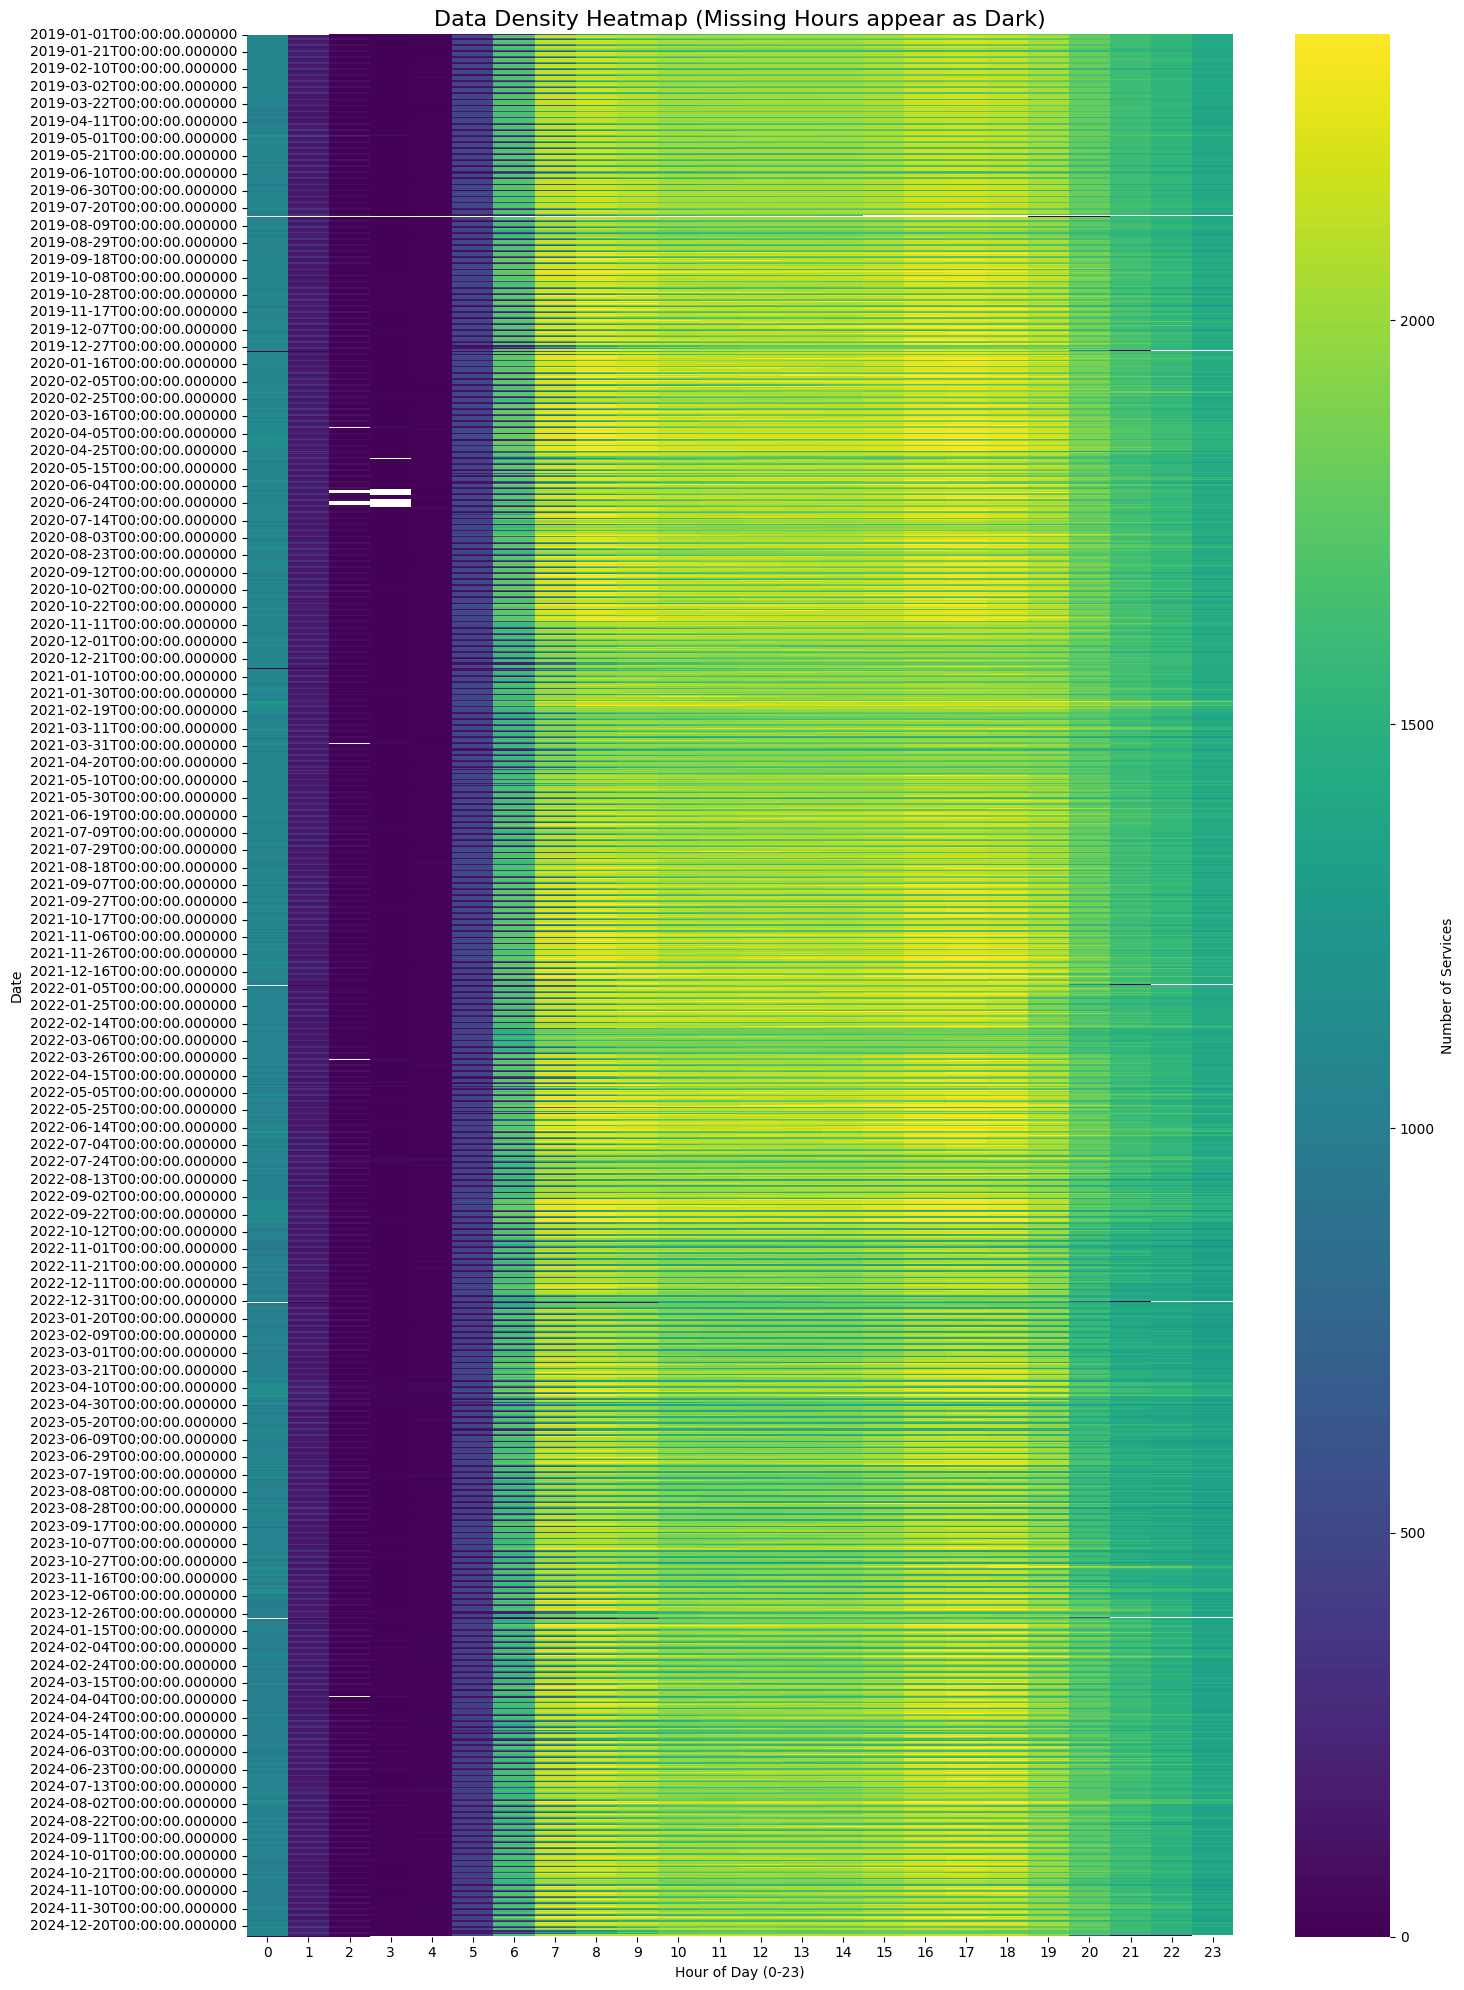

Data Completeness Score: 99.82%
Total Missing/Empty Hours: 95 out of 52632


In [ ]:
# --- Cell: Hourly Data Integrity Check (Heatmap) ---

print("Scanning hourly data density...")

# 1. SQL: Count rows per Date + Hour
# We group by Date and Hour to see "How many trains ran in this specific hour?"
density_query = """
    SELECT 
        CAST(arrival_time AS DATE) as service_date,
        HOUR(arrival_time) as hour_of_day,
        COUNT(*) as record_count
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1, 2
"""
df_density = con.execute(density_query).df()

# 2. Pivot for Heatmap
# Index = Date, Columns = Hour (0-23), Values = Record Count
pivot_density = df_density.pivot(index='service_date', columns='hour_of_day', values='record_count')

# 3. Reindex to ensure ALL dates are present (even empty ones)
# This fills the "missing days" we found earlier with NaNs so they show up as white gaps
all_dates = pd.date_range(start=pivot_density.index.min(), end=pivot_density.index.max(), freq='D')
pivot_density = pivot_density.reindex(all_dates)

# 4. Plotting
# We might need to downsample if you have 10 years of data (3650 rows is a lot for a heatmap)
# If the plot is too tall, we slice it or resample.
plt.figure(figsize=(15, 20)) # Tall plot to fit years
sns.heatmap(
    pivot_density, 
    cmap="viridis", 
    cbar_kws={'label': 'Number of Services'},
    vmin=0, 
    vmax=pivot_density.quantile(0.95).max() # Cap color scale at 95th percentile to handle outliers
)

plt.title("Data Density Heatmap (Missing Hours appear as Dark)", fontsize=16)
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Date")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Report Total Empty Hours
# An "Empty Hour" is a cell in this table that is NaN or 0
total_hours_possible = pivot_density.size
missing_hours_count = pivot_density.isna().sum().sum() + (pivot_density == 0).sum().sum()
completeness_pct = 100 * (1 - (missing_hours_count / total_hours_possible))

print(f"Data Completeness Score: {completeness_pct:.2f}%")
print(f"Total Missing/Empty Hours: {missing_hours_count} out of {total_hours_possible}")

### Network level 

Class balance arrival delay of all services: base line for binary classification

TODO: fix heatmap

TODO: class balance depends on prediction objective

Summarizing Dataset...
   total_stops               first_train                last_train  \
0     83492358 2019-01-01 02:12:00+01:00 2025-01-01 02:51:00+01:00   

   global_avg_delay  
0          0.011708  


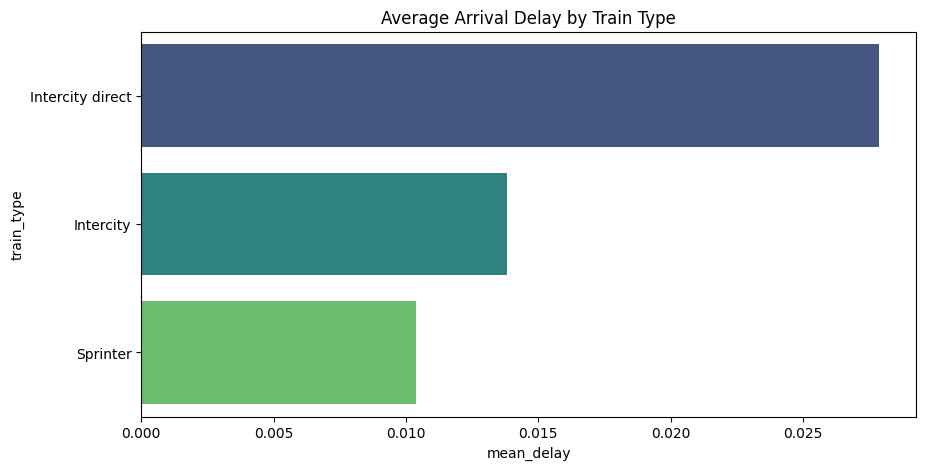

Calculating Class Balance...
                     status     count  percentage
0  No Delay (On Time/Early)  57789434   76.601562
1                   Delayed  17652153   23.398438


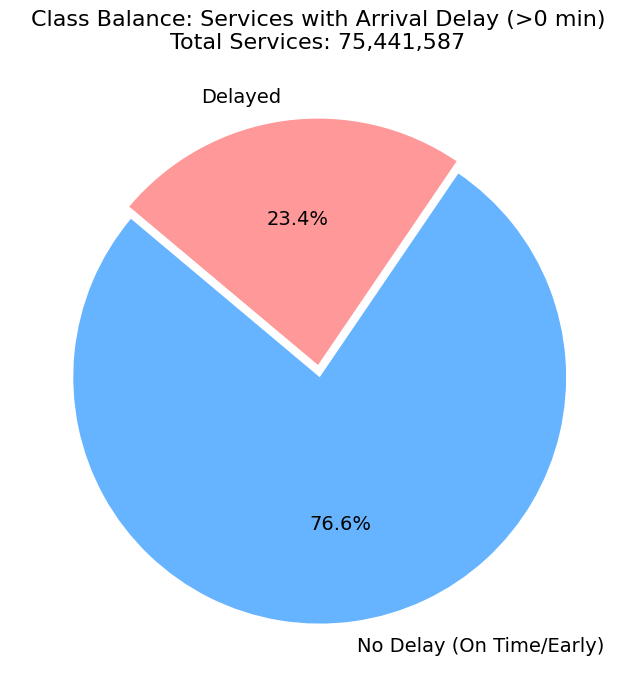

In [21]:
# --- A. General Summary ---
print("Summarizing Dataset...")
summary = con.execute("""
    SELECT 
        COUNT(*) as total_stops,
        MIN(arrival_time) as first_train,
        MAX(arrival_time) as last_train,
        AVG(arrival_delay_min) as global_avg_delay
    FROM services
""").df()
print(summary)

# # --- B. Delay Heatmap (Day of Week vs Hour) ---
# print("\nGenerating Heatmap Data...")
# heatmap_query = """
#     SELECT 
#         DAYOFWEEK(arrival_time) as day_idx, -- 1=Monday, 7=Sunday
#         HOUR(arrival_time) as hour_idx,
#         AVG(arrival_delay_min) as mean_delay
#     FROM services
#     WHERE arrival_time IS NOT NULL
#     GROUP BY 1, 2
# """
# df_heat = con.execute(heatmap_query).df()
# pivot_heat = df_heat.pivot(index='day_idx', columns='hour_idx', values='mean_delay')

# plt.figure(figsize=(12, 6))
# sns.heatmap(pivot_heat, cmap="RdYlGn_r", center=5, annot=False)
# plt.title("Average Delay (Minutes) by Day and Hour")
# plt.xlabel("Hour of Day")
# plt.ylabel("Day of Week (1=Mon)")
# plt.show()

# --- C. Delays per Train Type ---
df_type = con.execute("""
    SELECT train_type, AVG(arrival_delay_min) as mean_delay, COUNT(*) as count
    FROM services
    GROUP BY 1 HAVING count > 1000
    ORDER BY 2 DESC
""").df()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_type, x='mean_delay', y='train_type', palette="viridis", hue='train_type', legend=False)
plt.title("Average Arrival Delay by Train Type")
plt.show()


# --- Cell: Class Balance (Delayed vs No Delay) ---

print("Calculating Class Balance...")

# 1. SQL Query to categorize and count
# 'arrival_delay_min' > 0 means delayed.
balance_query = """
    SELECT 
        CASE 
            WHEN arrival_delay_min > 0 THEN 'Delayed'
            ELSE 'No Delay (On Time/Early)'
        END as status,
        COUNT(*) as count
    FROM services
    WHERE arrival_delay_min IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
"""

df_balance = con.execute(balance_query).df()

# 2. Calculate Percentages
total_services = df_balance['count'].sum()
df_balance['percentage'] = (df_balance['count'] / total_services) * 100

print(df_balance)

# 3. Plotting the Pie Chart
plt.figure(figsize=(8, 8))

# Define colors: Green for no delay, Red for delayed
colors = ['#ff9999' if status == 'Delayed' else '#66b3ff' for status in df_balance['status']]

plt.pie(
    df_balance['count'], 
    labels=df_balance['status'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    explode=(0.05, 0), # Slightly "explode" the first slice to emphasize it
    textprops={'fontsize': 14}
)

plt.title(f'Class Balance: Services with Arrival Delay (>0 min)\nTotal Services: {total_services:,}', fontsize=16)
plt.show()

We check the longest period that went by without any delay across the whole train network of NS

In [ ]:
# --- Max Time Without Delays (The "Clean Network" Metric) ---
# Logic: We find all timestamps where a delay > 5 min or > 1 occurred.
# We sort them and find the largest gap between two consecutive delay events.

gap_query = """
    WITH severe_delays AS (
        SELECT arrival_time
        FROM services
        WHERE arrival_delay_min > 0 -- Threshold for 'Delay'
        AND arrival_time IS NOT NULL
    ),
    ordered_delays AS (
        SELECT 
            arrival_time, 
            LEAD(arrival_time) OVER (ORDER BY arrival_time) as next_delay_time
        FROM severe_delays
    ),
    gaps AS (
        SELECT 
            arrival_time, 
            date_diff('minute', arrival_time, next_delay_time) as gap_minutes
        FROM ordered_delays
        WHERE next_delay_time IS NOT NULL
    )
    SELECT 
        MAX(gap_minutes) / 60.0 as max_hours_clean,
        AVG(gap_minutes) as avg_minutes_clean
    FROM gaps
"""

gap_query_five_mins = """
    WITH severe_delays AS (
        SELECT arrival_time
        FROM services
        WHERE arrival_delay_min > 5 -- Threshold for 'Delay'
        AND arrival_time IS NOT NULL
    ),
    ordered_delays AS (
        SELECT 
            arrival_time, 
            LEAD(arrival_time) OVER (ORDER BY arrival_time) as next_delay_time
        FROM severe_delays
    ),
    gaps AS (
        SELECT 
            arrival_time, 
            date_diff('minute', arrival_time, next_delay_time) as gap_minutes
        FROM ordered_delays
        WHERE next_delay_time IS NOT NULL
    )
    SELECT 
        MAX(gap_minutes) / 60.0 as max_hours_clean,
        AVG(gap_minutes) as avg_minutes_clean
    FROM gaps
"""

print("Calculating Network Resilience...")
df_gaps = con.execute(gap_query).df()
print(f"Longest period the ENTIRE network ran without any delays (>1m): {df_gaps['max_hours_clean'][0] // 24} days")
df_gaps_five = con.execute(gap_query_five_mins).df()
print(f"Longest period the ENTIRE network ran without any delays (>5m): {df_gaps_five['max_hours_clean'][0] // 24} days")

Calculating Network Resilience...
Longest period the ENTIRE network ran without any delays (>1m): 2.0 days
Longest period the ENTIRE network ran without any delays (>5m): 140.0 days


#### Arrival Delay per Time horizon level (hourly, weekly and per week)
Drop in week 52 due to time series -> TODO: doublecheck what to do with it from course

Analyzing Hourly Delays...
Analyzing Daily Delays...
Analyzing Weekly Delays...


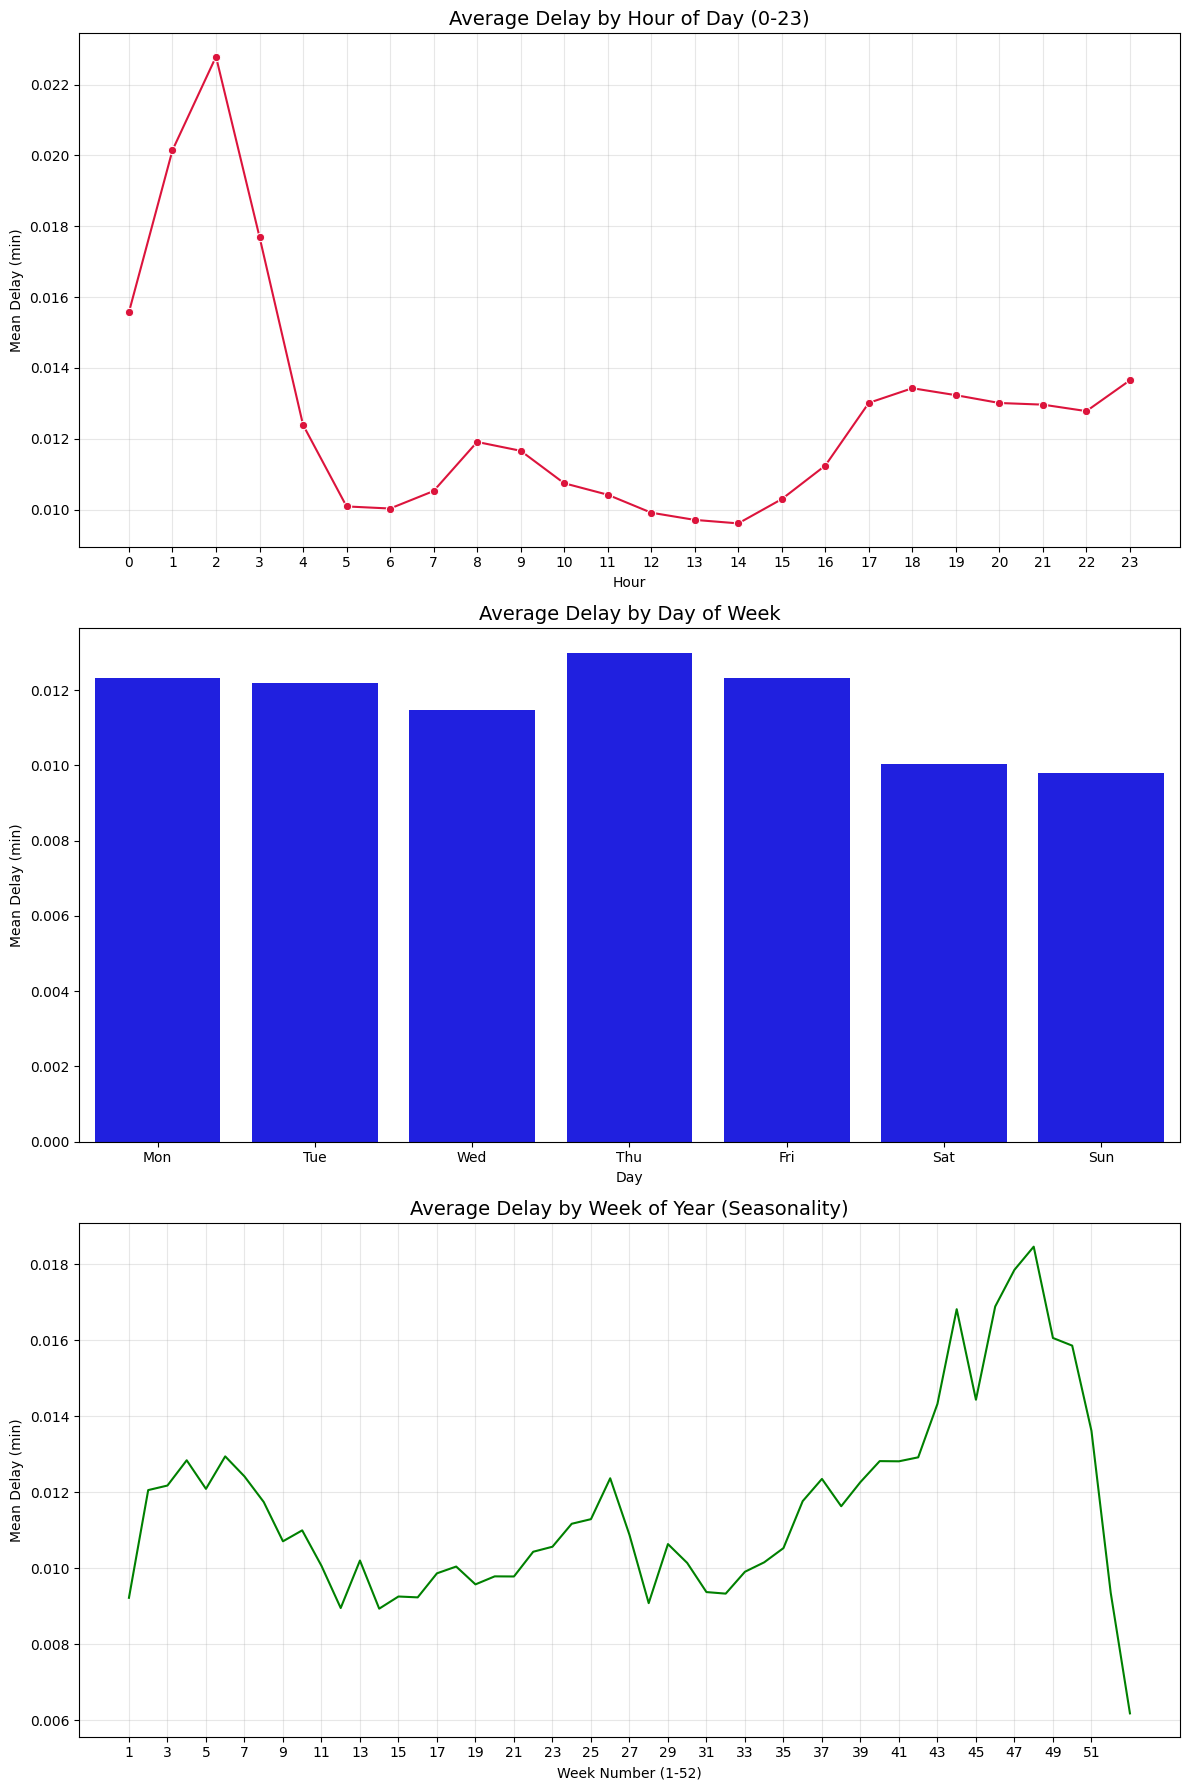

In [23]:
# --- Cell: Temporal Patterns of Delay ---

# 1. Hourly Trend (The "Commuter Curve")
print("Analyzing Hourly Delays...")
hourly_df = con.execute("""
    SELECT 
        HOUR(arrival_time) as hour_of_day,
        AVG(arrival_delay_min) as mean_delay,
        COUNT(*) as traffic_volume
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

# 2. Daily Trend (Day of Week)
print("Analyzing Daily Delays...")
daily_df = con.execute("""
    SELECT 
        ISODOW(arrival_time) as day_idx,     
        CASE ISODOW(arrival_time)
            WHEN 1 THEN 'Mon' WHEN 2 THEN 'Tue' WHEN 3 THEN 'Wed'
            WHEN 4 THEN 'Thu' WHEN 5 THEN 'Fri' WHEN 6 THEN 'Sat' WHEN 7 THEN 'Sun'
        END as day_name,
        AVG(arrival_delay_min) as mean_delay
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1
""").df()

# 3. Weekly Trend (Seasonal Seasonality)
print("Analyzing Weekly Delays...")
weekly_df = con.execute("""
    SELECT 
        WEEK(arrival_time) as week_number,
        AVG(arrival_delay_min) as mean_delay
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Hourly
sns.lineplot(data=hourly_df, x='hour_of_day', y='mean_delay', ax=axes[0], marker='o', color='crimson')
axes[0].set_title('Average Delay by Hour of Day (0-23)', fontsize=14)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Delay (min)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24))

# Plot 2: Daily (Day of Week)
sns.barplot(data=daily_df, x='day_name', y='mean_delay', ax=axes[1], color='blue')
axes[1].set_title('Average Delay by Day of Week', fontsize=14)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Mean Delay (min)')

# Plot 3: Weekly (Yearly Seasonality)
sns.lineplot(data=weekly_df, x='week_number', y='mean_delay', ax=axes[2], color='green')
axes[2].set_title('Average Delay by Week of Year (Seasonality)', fontsize=14)
axes[2].set_xlabel('Week Number (1-52)')
axes[2].set_ylabel('Mean Delay (min)')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(range(1, 53, 2)) # Label every 2nd week

plt.tight_layout()
plt.show()

## Disruptions Dataset

This dataset refers to major disruptions recorded by NS (affecting multiple trains/lines)

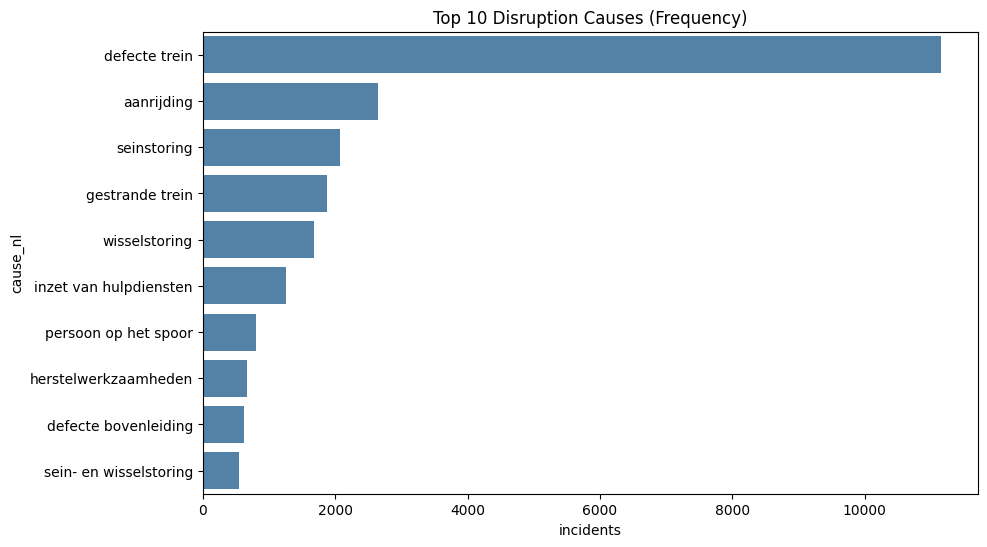

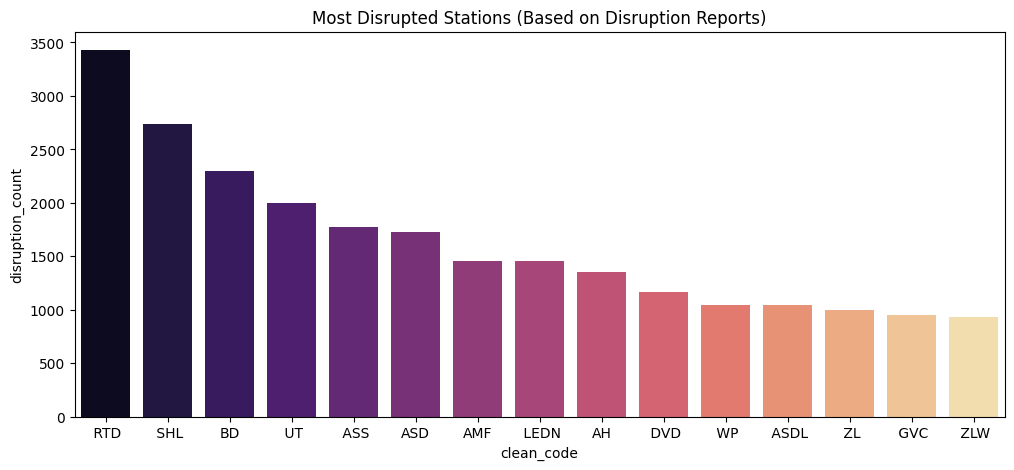

In [9]:
# --- A. Top Disruption Causes ---
df_causes = con.execute("""
    SELECT cause_nl, COUNT(*) as incidents, AVG(duration_minutes) as avg_duration
    FROM disruptions
    WHERE cause_nl IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 10
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_causes, x='incidents', y='cause_nl', color='steelblue')
plt.title("Top 10 Disruption Causes (Frequency)")
plt.show()

# --- B. Station Vulnerability (Unnesting the list) ---
df_vuln = con.execute("""
    WITH unpacked AS (
        SELECT UNNEST(station_array) as clean_code, duration_minutes
        FROM disruptions
    )
    SELECT clean_code, COUNT(*) as disruption_count
    FROM unpacked
    WHERE clean_code != ''
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 15
""").df()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_vuln, x='clean_code', y='disruption_count', palette="magma", hue='clean_code', legend=False)
plt.title("Most Disrupted Stations (Based on Disruption Reports)")
plt.show()

## Disruptions as % of Services

Missing disruptions

i.e. if disruptions (rdt_id) in services (rdt_id) & Only arrival delay, excl cancellations

Analyzing Missing Disruptions (Events with zero matching trains)...
Total Disruption Events (rdt_id):  31,163
✅ Matched with Services:           24,128 (77.4%)
⚠️ Missing (No matching trains):    7,035 (22.6%)


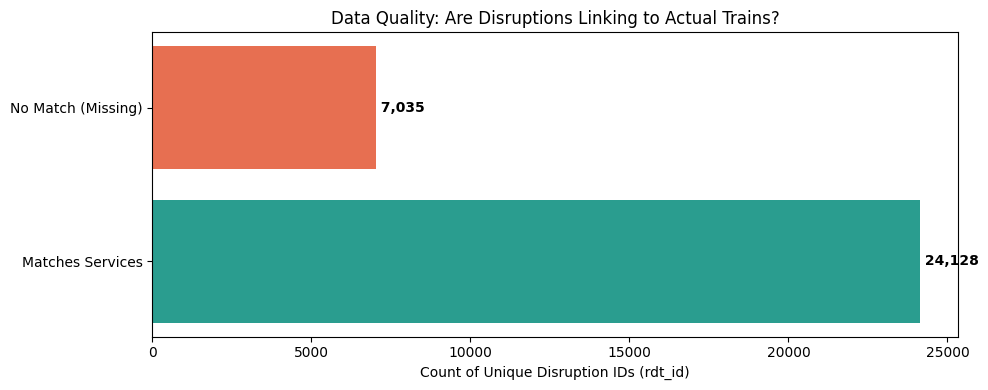


Top Causes of Missing Disruptions (Events that didn't affect any logged train):
          cause_nl  count
0    defecte trein  10697
1       aanrijding   2589
2      seinstoring   1985
3  gestrande trein   1777
4    wisselstoring   1573


In [29]:
# --- Cell: Missing Disruption Analysis ---
# Checking: Which disruption IDs (rdt_id) have NO matching services?

print("Analyzing Missing Disruptions (Events with zero matching trains)...")

# 1. Prepare Flattened Disruptions (if not already done in previous cells)
con.execute("""
    CREATE OR REPLACE TEMP TABLE flat_disruptions AS
    SELECT 
        rdt_id,
        cause_nl,
        UNNEST(station_array) as station_code,
        start_time,
        end_time
    FROM disruptions
    WHERE duration_minutes > 0 
""")

# 2. Left Join Disruptions -> Services to find non-matches
missing_query = """
    WITH disruption_status AS (
        SELECT 
            d.rdt_id,
            d.cause_nl,
            -- Check if at least ONE service matches this disruption event
            COUNT(s.service_id) as matched_service_count
        FROM flat_disruptions d
        LEFT JOIN services s 
          ON d.station_code = s.station_code 
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        GROUP BY 1, 2
    )
    SELECT 
        COUNT(*) as total_disruption_events,
        SUM(CASE WHEN matched_service_count > 0 THEN 1 ELSE 0 END) as matched_events,
        SUM(CASE WHEN matched_service_count = 0 THEN 1 ELSE 0 END) as missing_events,
        
        -- Calculate Percentage
        100.0 * SUM(CASE WHEN matched_service_count = 0 THEN 1 ELSE 0 END) / COUNT(*) as missing_percentage
    FROM disruption_status
"""

df_missing = con.execute(missing_query).df()
stats = df_missing.iloc[0]

# --- Reporting ---
print(f"Total Disruption Events (rdt_id):  {int(stats['total_disruption_events']):,}")
print(f"✅ Matched with Services:           {int(stats['matched_events']):,} ({100-stats['missing_percentage']:.1f}%)")
print(f"⚠️ Missing (No matching trains):    {int(stats['missing_events']):,} ({stats['missing_percentage']:.1f}%)")

# --- Visualization ---
plt.figure(figsize=(10, 4))
plt.barh(
    ['Matches Services', 'No Match (Missing)'], 
    [stats['matched_events'], stats['missing_events']], 
    color=['#2a9d8f', '#e76f51']
)
plt.title("Data Quality: Are Disruptions Linking to Actual Trains?")
plt.xlabel("Count of Unique Disruption IDs (rdt_id)")

# Add text labels
for index, value in enumerate([stats['matched_events'], stats['missing_events']]):
    plt.text(value, index, f" {int(value):,}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Optional: Peek at the Missing ones ---
# Why are they missing? Let's look at the top causes.
if stats['missing_events'] > 0:
    print("\nTop Causes of Missing Disruptions (Events that didn't affect any logged train):")
    missing_cause_query = """
        SELECT 
            d.cause_nl, 
            COUNT(DISTINCT d.rdt_id) as count
        FROM flat_disruptions d
        LEFT JOIN services s 
          ON d.station_code = s.station_code 
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.service_id IS NULL -- The filter for missing/unmatched
        GROUP BY 1
        ORDER BY 2 DESC
        LIMIT 5
    """
    print(con.execute(missing_cause_query).df())

% of services

1. Preparing spatial-temporal join helper...
2. Calculating Impact Metrics (this may take a moment)...

=== 📊 Disruption Impact Report ===
1. Total Services Analyzed:       16,955,106
2. Services with Major Disruption: 4.33%
3. Delay Caused by Major Events:   3.01% of all delay minutes
   (Remaining 96.99% is likely 'minor' operations delay)
----------------------------------------
4. Total Cancellations:           702,088
5. 'Ghost' Cancellations:         68.95%
   (Services cancelled without a matching record in the Disruptions table)


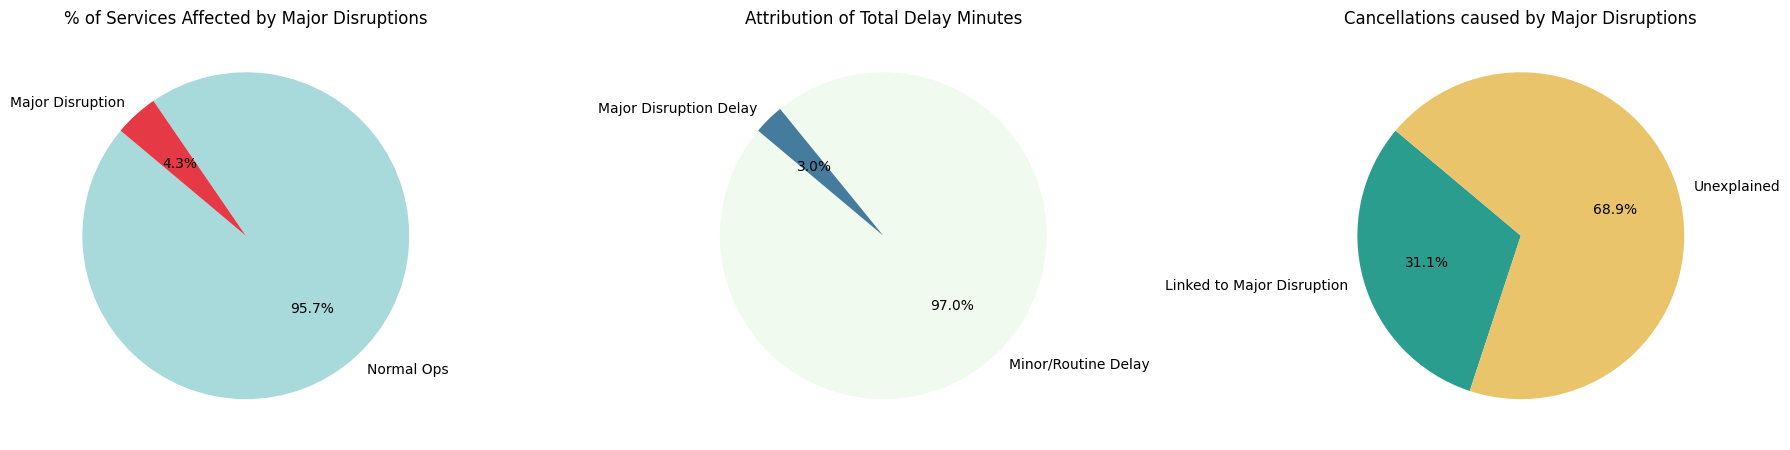

In [24]:
# --- Cell: Disruption Impact Analysis ---

print("1. Preparing spatial-temporal join helper...")

# A. Flatten the disruptions (Unnest the station list) so we can join on Station Code
# We filter out disruptions with zero duration or invalid times to keep joins fast.
con.execute("""
    CREATE OR REPLACE TEMP TABLE flat_disruptions AS
    SELECT 
        rdt_id,
        cause_nl,
        UNNEST(station_array) as station_code,
        start_time,
        end_time
    FROM disruptions
    WHERE duration_minutes > 0 
      AND start_time < end_time
""")

# B. Perform the "Big Join" (Range Join)
# This flags every service as 'Linked to Disruption' or 'Not Linked'
# Note: We use LEFT JOIN to keep all services, even those without disruptions.
print("2. Calculating Impact Metrics (this may take a moment)...")

impact_query = """
    WITH joined_data AS (
        SELECT 
            s.service_id,
            s.is_cancelled,
            s.arrival_delay_min,
            -- Check if this service falls into ANY disruption window at this station
            MAX(CASE WHEN d.rdt_id IS NOT NULL THEN 1 ELSE 0 END) as has_major_disruption
        FROM services s
        LEFT JOIN flat_disruptions d
          ON s.station_code = d.station_code
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.arrival_time IS NOT NULL -- Exclude arrival no planned
        GROUP BY 1, 2, 3
    )
    SELECT 
        -- Metric 1: Service Impact
        COUNT(*) as total_services,
        SUM(has_major_disruption) as disrupted_services,
        100.0 * SUM(has_major_disruption) / COUNT(*) as pct_services_disrupted,
        
        -- Metric 2: Ghost Cancellations (Cancelled but no disruption record found?)
        SUM(CASE WHEN is_cancelled=true THEN 1 ELSE 0 END) as total_cancellations,
        SUM(CASE WHEN is_cancelled=true AND has_major_disruption=1 THEN 1 ELSE 0 END) as explained_cancellations,
        100.0 * SUM(CASE WHEN is_cancelled=true AND has_major_disruption=0 THEN 1 ELSE 0 END) / NULLIF(SUM(CASE WHEN is_cancelled=true THEN 1 ELSE 0 END),0) as pct_unexplained_cancellations,

        -- Metric 3: Delay Attribution
        SUM(arrival_delay_min) as total_delay_minutes,
        SUM(CASE WHEN has_major_disruption=1 THEN arrival_delay_min ELSE 0 END) as disruption_caused_delay,
        100.0 * SUM(CASE WHEN has_major_disruption=1 THEN arrival_delay_min ELSE 0 END) / NULLIF(SUM(arrival_delay_min), 0) as pct_delay_from_major
    FROM joined_data
"""

df_impact = con.execute(impact_query).df()

# --- Reporting ---
print("\n=== 📊 Disruption Impact Report ===")
metrics = df_impact.iloc[0]

print(f"1. Total Services Analyzed:       {int(metrics['total_services']):,}")
print(f"2. Services with Major Disruption: {metrics['pct_services_disrupted']:.2f}%")
print(f"3. Delay Caused by Major Events:   {metrics['pct_delay_from_major']:.2f}% of all delay minutes")
print(f"   (Remaining {100-metrics['pct_delay_from_major']:.2f}% is likely 'minor' operations delay)")
print("-" * 40)
print(f"4. Total Cancellations:           {int(metrics['total_cancellations']):,}")
print(f"5. 'Ghost' Cancellations:         {metrics['pct_unexplained_cancellations']:.2f}%")
print("   (Services cancelled without a matching record in the Disruptions table)")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Services Affected
axes[0].pie(
    [metrics['total_services'] - metrics['disrupted_services'], metrics['disrupted_services']],
    labels=['Normal Ops', 'Major Disruption'],
    autopct='%1.1f%%',
    colors=['#a8dadc', '#e63946'],
    startangle=140
)
axes[0].set_title("% of Services Affected by Major Disruptions")

# Plot 2: Delay Attribution
axes[1].pie(
    [metrics['total_delay_minutes'] - metrics['disruption_caused_delay'], metrics['disruption_caused_delay']],
    labels=['Minor/Routine Delay', 'Major Disruption Delay'],
    autopct='%1.1f%%',
    colors=['#f1faee', '#457b9d'],
    startangle=140
)
axes[1].set_title("Attribution of Total Delay Minutes")

# Plot 3: Cancellation Explanation
axes[2].pie(
    [metrics['explained_cancellations'], metrics['total_cancellations'] - metrics['explained_cancellations']],
    labels=['Linked to Major Disruption', 'Unexplained'],
    autopct='%1.1f%%',
    colors=['#2a9d8f', '#e9c46a'],
    startangle=140
)
axes[2].set_title("Cancellations caused by Major Disruptions")

plt.tight_layout()
plt.show()

Calculating count-based impact metrics...
Total Delayed Trains (>5 min): 82
 - Caused by Major Disruption: 2.4%
 - Routine/Minor Causes:       97.6%


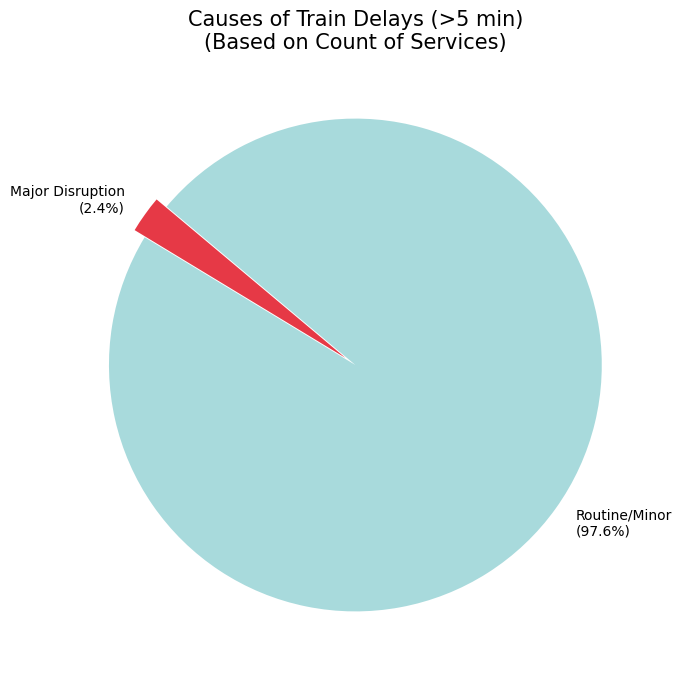

In [25]:
# --- Cell: Disruption Impact (Count of Delayed Trains) ---

print("Calculating count-based impact metrics...")

impact_count_query = """
    WITH joined_data AS (
        SELECT 
            s.service_id,
            s.arrival_delay_min,
            -- Flag if this specific train matches a disruption window
            MAX(CASE WHEN d.rdt_id IS NOT NULL THEN 1 ELSE 0 END) as linked_to_disruption
        FROM services s
        LEFT JOIN flat_disruptions d
          ON s.station_code = d.station_code
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.arrival_time IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT 
        -- 1. Define the Population: All trains with Significant Delay (> 5 min)
        SUM(CASE WHEN arrival_delay_min >= 5 THEN 1 ELSE 0 END) as total_delayed_trains,
        
        -- 2. Count how many of those match a Major Disruption
        SUM(CASE WHEN arrival_delay_min >= 5 AND linked_to_disruption=1 THEN 1 ELSE 0 END) as explained_delays,
        
        -- 3. The remaining are "Unexplained" (Routine/Minor operational issues)
        SUM(CASE WHEN arrival_delay_min >= 5 AND linked_to_disruption=0 THEN 1 ELSE 0 END) as unexplained_delays
    FROM joined_data
"""

df_impact_count = con.execute(impact_count_query).df()
metrics = df_impact_count.iloc[0]

# --- Reporting ---
explained_pct = (metrics['explained_delays'] / metrics['total_delayed_trains']) * 100
unexplained_pct = (metrics['unexplained_delays'] / metrics['total_delayed_trains']) * 100

print(f"Total Delayed Trains (>5 min): {int(metrics['total_delayed_trains']):,}")
print(f" - Caused by Major Disruption: {explained_pct:.1f}%")
print(f" - Routine/Minor Causes:       {unexplained_pct:.1f}%")

# --- Plotting the New Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    [metrics['explained_delays'], metrics['unexplained_delays']],
    labels=[f'Major Disruption\n({explained_pct:.1f}%)', f'Routine/Minor\n({unexplained_pct:.1f}%)'],
    colors=['#e63946', '#a8dadc'], # Red for disruption, Blue for routine
    autopct='', # We put the pct in the label manually above
    startangle=140,
    explode=(0.05, 0) # Highlight the disruption slice
)
plt.title("Causes of Train Delays (>5 min)\n(Based on Count of Services)", fontsize=15)
plt.show()

Calculating count-based impact metrics...
Total Delayed Trains (>0 min): 16,591,155
 - Caused by Major Disruption: 4.4%
 - Routine/Minor Causes:       95.6%


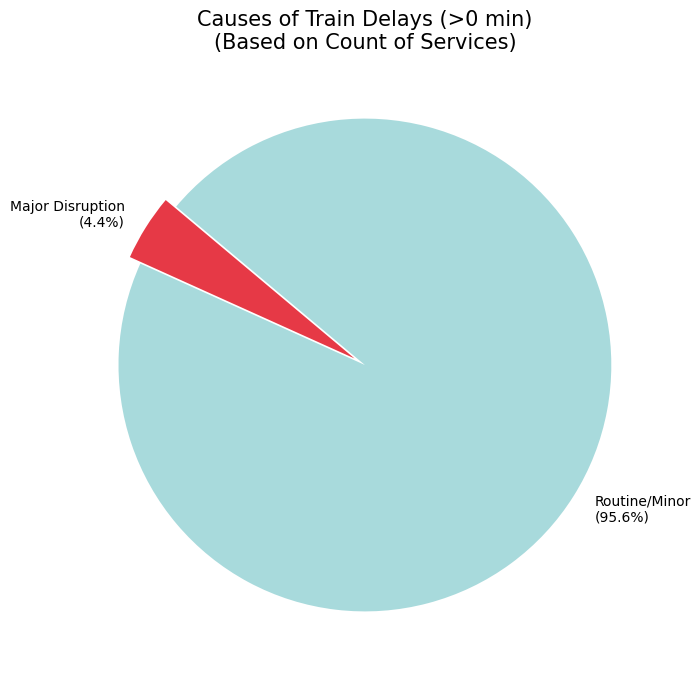

In [26]:
# --- Cell: Disruption Impact (Count of Delayed Trains) ---

print("Calculating count-based impact metrics...")

impact_count_query = """
    WITH joined_data AS (
        SELECT 
            s.service_id,
            s.arrival_delay_min,
            -- Flag if this specific train matches a disruption window
            MAX(CASE WHEN d.rdt_id IS NOT NULL THEN 1 ELSE 0 END) as linked_to_disruption
        FROM services s
        LEFT JOIN flat_disruptions d
          ON s.station_code = d.station_code
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.arrival_time IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT 
        -- 1. Define the Population: All trains with Significant Delay (> 0 min)
        SUM(CASE WHEN arrival_delay_min >= 0 THEN 1 ELSE 0 END) as total_delayed_trains,
        
        -- 2. Count how many of those match a Major Disruption
        SUM(CASE WHEN arrival_delay_min >= 0 AND linked_to_disruption=1 THEN 1 ELSE 0 END) as explained_delays,
        
        -- 3. The remaining are "Unexplained" (Routine/Minor operational issues)
        SUM(CASE WHEN arrival_delay_min >= 0 AND linked_to_disruption=0 THEN 1 ELSE 0 END) as unexplained_delays
    FROM joined_data
"""

df_impact_count = con.execute(impact_count_query).df()
metrics = df_impact_count.iloc[0]

# --- Reporting ---
explained_pct = (metrics['explained_delays'] / metrics['total_delayed_trains']) * 100
unexplained_pct = (metrics['unexplained_delays'] / metrics['total_delayed_trains']) * 100

print(f"Total Delayed Trains (>0 min): {int(metrics['total_delayed_trains']):,}")
print(f" - Caused by Major Disruption: {explained_pct:.1f}%")
print(f" - Routine/Minor Causes:       {unexplained_pct:.1f}%")

# --- Plotting the New Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    [metrics['explained_delays'], metrics['unexplained_delays']],
    labels=[f'Major Disruption\n({explained_pct:.1f}%)', f'Routine/Minor\n({unexplained_pct:.1f}%)'],
    colors=['#e63946', '#a8dadc'], # Red for disruption, Blue for routine
    autopct='', # We put the pct in the label manually above
    startangle=140,
    explode=(0.05, 0) # Highlight the disruption slice
)
plt.title("Causes of Train Delays (>0 min)\n(Based on Count of Services)", fontsize=15)
plt.show()

## Weather Dataset


### Weather features per time horizon

Analyzing temperature_2m...
Analyzing rain...
Analyzing snowfall...
Analyzing snow_depth...
Analyzing wind_speed_10m...
Analyzing wind_gusts_10m...
Analyzing soil_temperature_0_to_7cm...


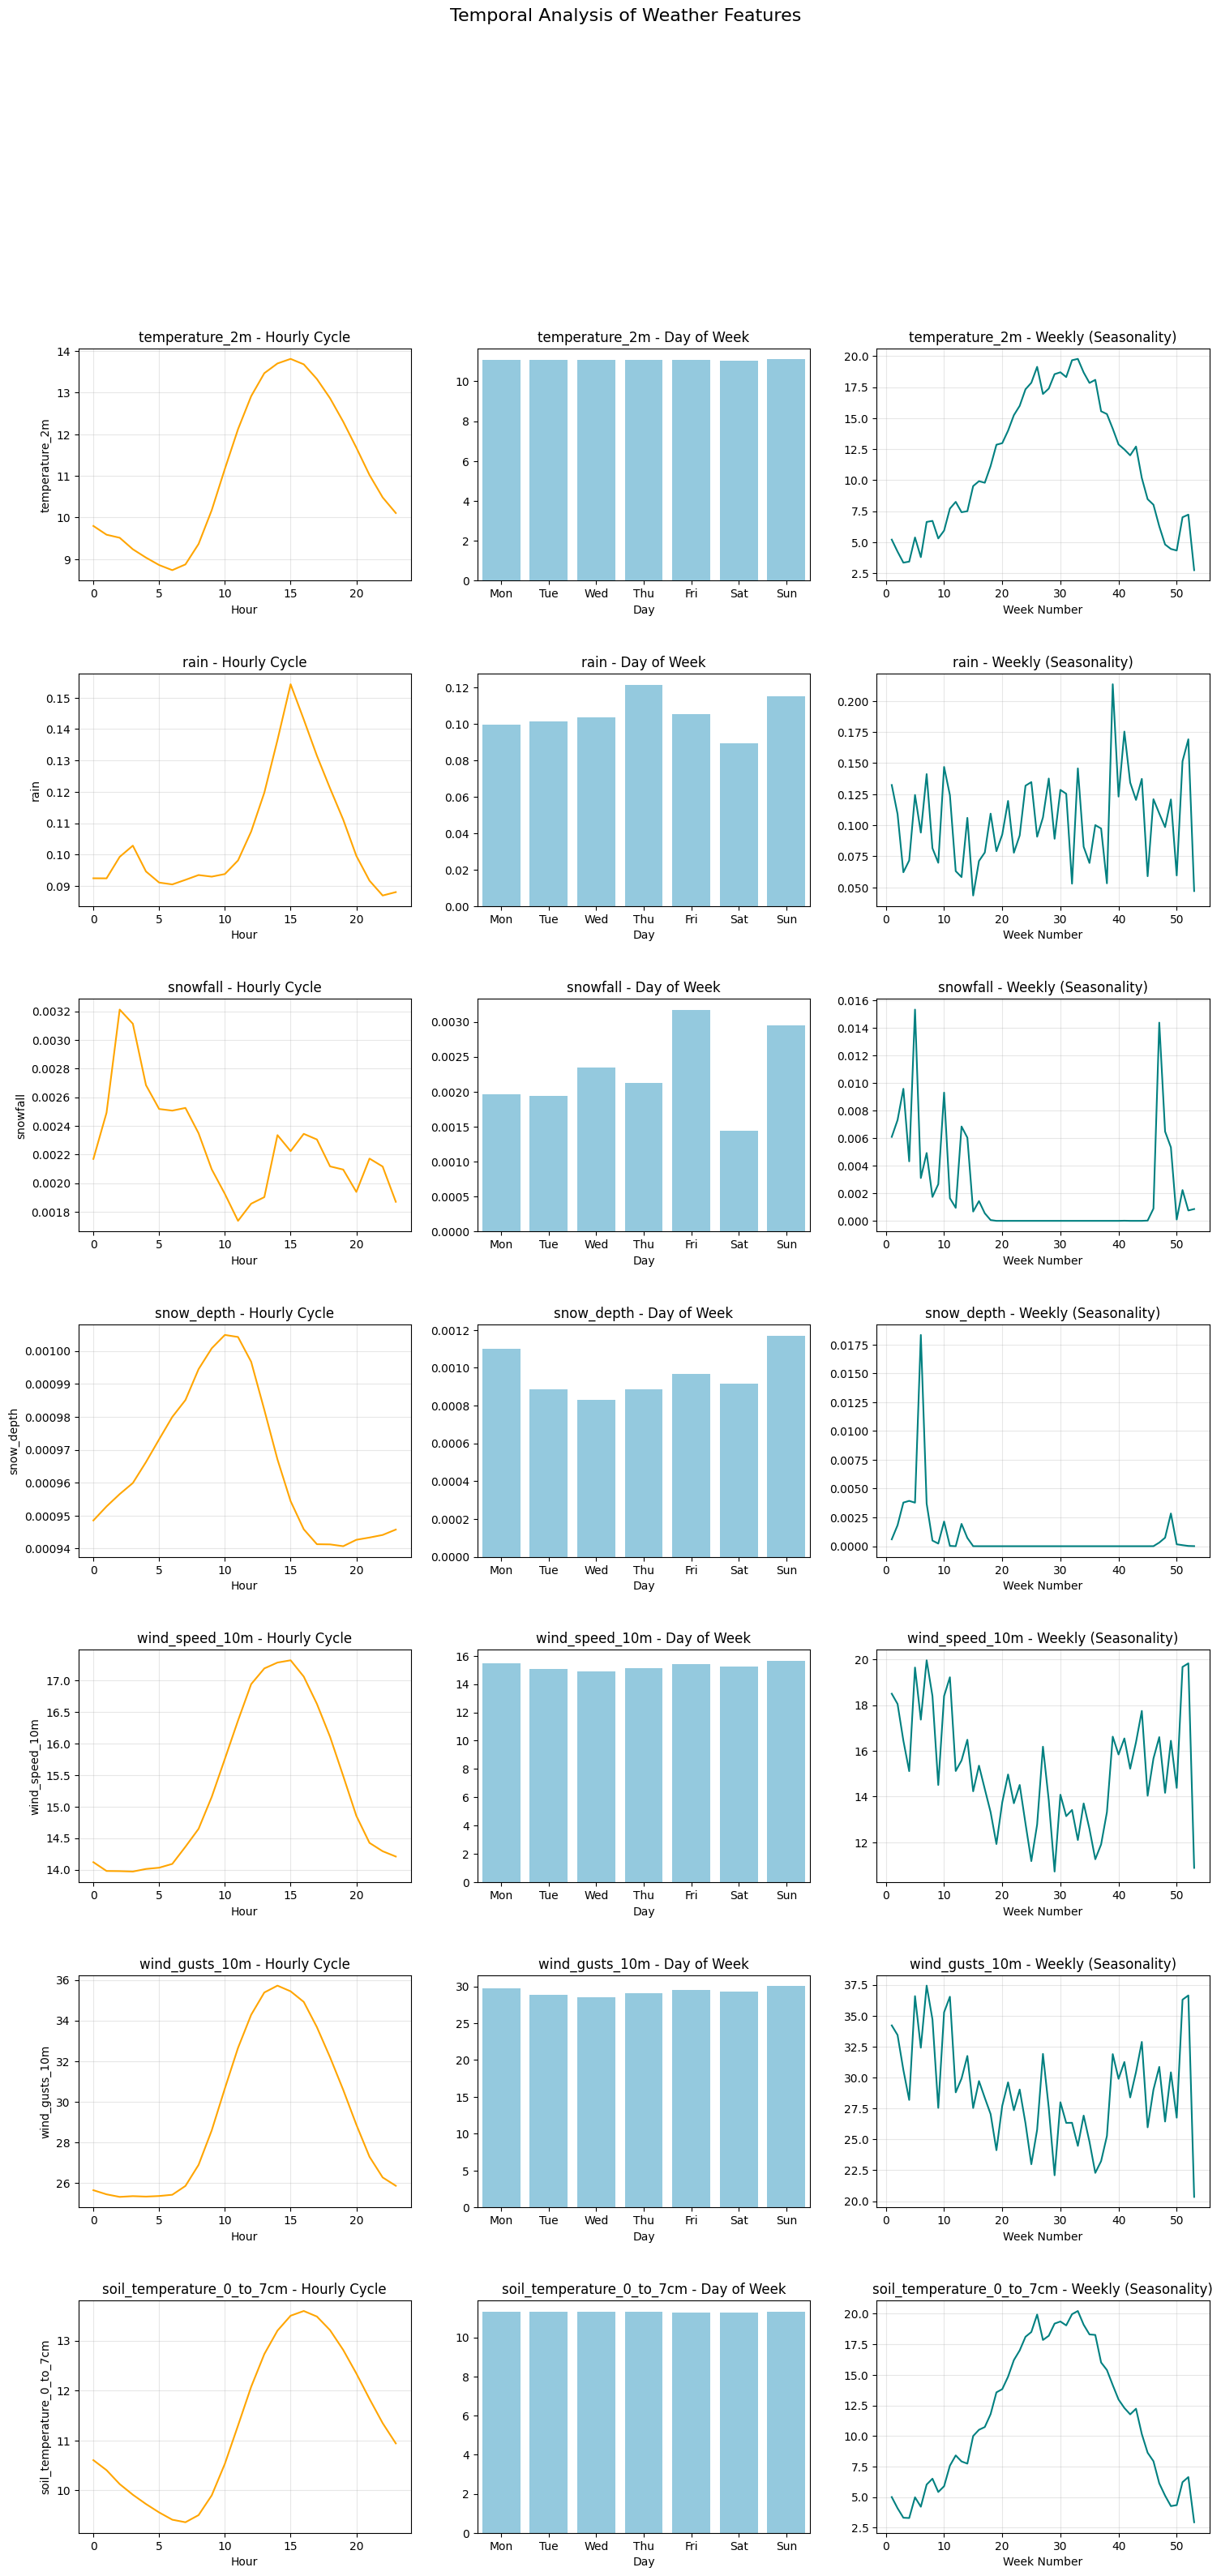

In [21]:
weather_features = [
    "temperature_2m", "rain", "snowfall", "snow_depth",
    "wind_speed_10m", "wind_gusts_10m", "soil_temperature_0_to_7cm"
]

# Set up the plot: One row per feature, 3 columns (Hourly, Daily, Weekly)
fig, axes = plt.subplots(len(weather_features), 3, figsize=(18, 5 * len(weather_features)))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

for i, feature in enumerate(weather_features):
    print(f"Analyzing {feature}...")
    
    # 1. Hourly Trend
    hourly_query = f"""
        SELECT 
            HOUR(time) as hour_of_day,
            AVG({feature}) as mean_val
        FROM raw_weather
        GROUP BY 1
        ORDER BY 1
    """
    df_hourly = con.execute(hourly_query).df()
    
    # 2. Daily Trend (Day of Week) - mostly to check for data bias
    daily_query = f"""
        SELECT 
            ISODOW(time) as day_idx,  
            CASE ISODOW(time)         
                WHEN 1 THEN 'Mon' WHEN 2 THEN 'Tue' WHEN 3 THEN 'Wed'
                WHEN 4 THEN 'Thu' WHEN 5 THEN 'Fri' WHEN 6 THEN 'Sat' 
                WHEN 7 THEN 'Sun'     
            END as day_name,
            AVG({feature}) as mean_val
        FROM raw_weather
        GROUP BY 1, 2
        ORDER BY 1
    """
    df_daily = con.execute(daily_query).df()
    
    # 3. Weekly Trend (Seasonality)
    weekly_query = f"""
        SELECT 
            WEEK(time) as week_number,
            AVG({feature}) as mean_val
        FROM raw_weather
        GROUP BY 1
        ORDER BY 1
    """
    df_weekly = con.execute(weekly_query).df()
    
    # --- Plotting ---
    
    # Hourly Plot
    sns.lineplot(data=df_hourly, x='hour_of_day', y='mean_val', ax=axes[i, 0], color='orange')
    axes[i, 0].set_title(f'{feature} - Hourly Cycle')
    axes[i, 0].set_ylabel(feature)
    axes[i, 0].set_xlabel("Hour")
    axes[i, 0].grid(True, alpha=0.3)
    
    # Daily Plot
    sns.barplot(data=df_daily, x='day_name', y='mean_val', ax=axes[i, 1], color='skyblue')
    axes[i, 1].set_title(f'{feature} - Day of Week')
    axes[i, 1].set_ylabel("") # Save space
    axes[i, 1].set_xlabel("Day")
    
    # Weekly Plot
    sns.lineplot(data=df_weekly, x='week_number', y='mean_val', ax=axes[i, 2], color='teal')
    axes[i, 2].set_title(f'{feature} - Weekly (Seasonality)')
    axes[i, 2].set_ylabel("") # Save space
    axes[i, 2].set_xlabel("Week Number")
    axes[i, 2].grid(True, alpha=0.3)

plt.suptitle("Temporal Analysis of Weather Features", fontsize=16, y=1.00)
plt.show()

### Weather Correlation arrival delays (WIP)
We check if theres a correlation between weather features and delay

TODO double check, takes 3min to run though check or remove later

Running Weather Correlation...


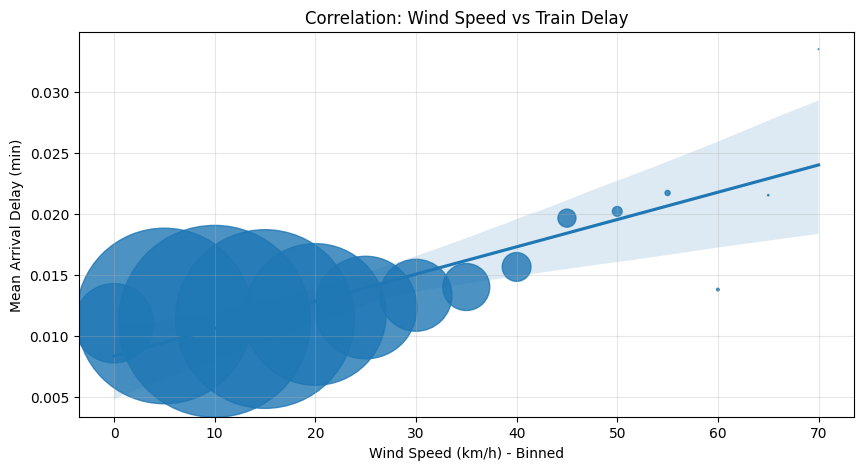

In [13]:
weather_query = """
    WITH weather_binned AS (
        SELECT 
            time, 
            station_code, -- ensure we select this to join on location
            FLOOR(wind_speed_10m / 5) * 5 as wind_bin
        FROM raw_weather
    )
    SELECT 
        w.wind_bin,
        AVG(s.arrival_delay_min) as mean_delay,
        COUNT(*) as sample_size
    FROM services s
    ASOF JOIN weather_binned w 
        ON s.station_code = w.station_code 
        AND s.arrival_time >= w.time -- <--- THE FIX: Use >= instead of =
    WHERE s.arrival_delay_min BETWEEN 0 AND 120 
    GROUP BY 1
    HAVING sample_size > 100
    ORDER BY 1
"""

print("Running Weather Correlation...")
try:
    df_weather = con.execute(weather_query).df()
    
    plt.figure(figsize=(10, 5))
    sns.regplot(data=df_weather, x='wind_bin', y='mean_delay', scatter_kws={'s': df_weather['sample_size']/1000})
    plt.title("Correlation: Wind Speed vs Train Delay")
    plt.xlabel("Wind Speed (km/h) - Binned")
    plt.ylabel("Mean Arrival Delay (min)")
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Query failed: {e}")
    print("Tip: If this returns Empty DataFrame, your Weather Station Codes might not match your Train Station Codes.")
    print("In that case, try removing 's.station_code = w.station_code' to test a global weather correlation.")

## Holidays Dataset

Mean delay higher in normal days normal days but probably due to larger sample size

-> outliers remove or include? (WHERE clause)

Analyzing Holiday Impact...
Impact Summary:
     day_type  mean_delay  total_trains
0  Normal Day    0.011794      81512490
1     Holiday    0.008128       1979868


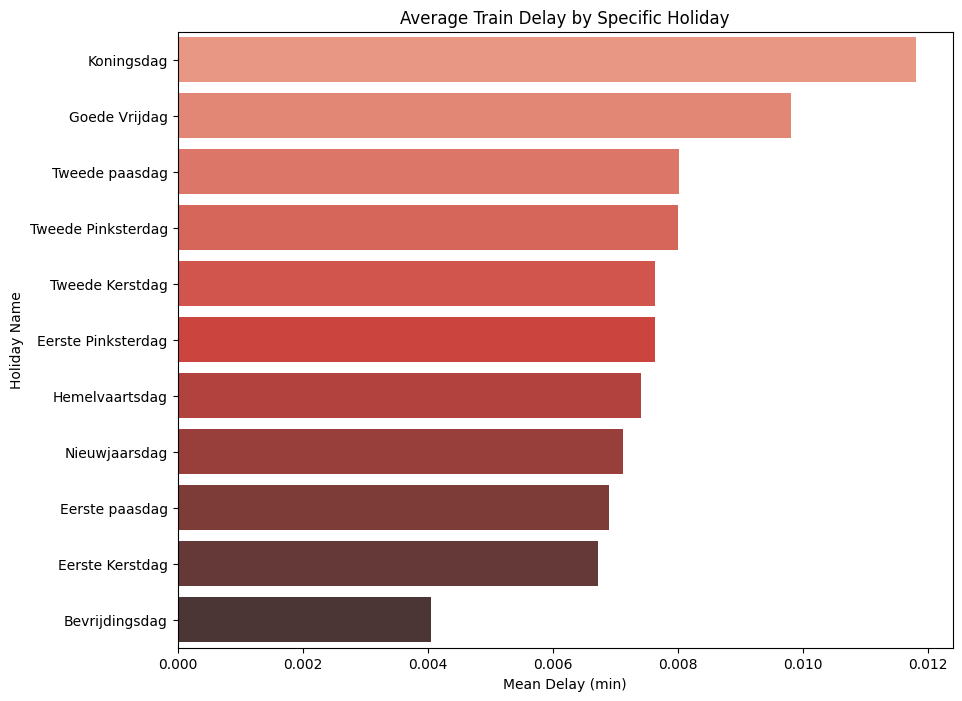

In [8]:
# --- Cell: Holiday Impact Analysis ---

# # 1. Register Holidays Table
# holiday_path = root_folder / "holidays/dutch_holidays_2019_2025.parquet"
# con.execute(f"CREATE OR REPLACE TABLE holidays AS SELECT * FROM read_parquet('{holiday_path}')")

# 2. Compare Delays: Holiday vs Normal Day
print("Analyzing Holiday Impact...")
holiday_query = """
    WITH data_labeled AS (
        SELECT 
            s.arrival_delay_min,
            CASE 
                -- Cast timestamp to date for the join
                WHEN h.date IS NOT NULL THEN 'Holiday' 
                ELSE 'Normal Day'
            END as day_type
        FROM services s
        -- JOIN CONDITION: Match Service Date to Holiday Date
        LEFT JOIN raw_holidays h ON s.service_date = CAST(h.date AS DATE)
        -- WHERE s.arrival_delay_min BETWEEN 0 AND 120 
    )
    SELECT 
        day_type,
        AVG(arrival_delay_min) as mean_delay,
        COUNT(*) as total_trains
    FROM data_labeled
    GROUP BY 1
"""
df_impact = con.execute(holiday_query).df()
print("Impact Summary:")
print(df_impact)

# 3. Specific Holiday Ranking (Which holiday is the worst?)
ranking_query = """
    SELECT 
        h.holiday_name,
        AVG(s.arrival_delay_min) as mean_delay,
        COUNT(*) as train_count
    FROM services s
    JOIN holidays h ON s.service_date = CAST(h.date AS DATE)
    GROUP BY 1
    HAVING train_count > 500 -- Ensure statistical significance
    ORDER BY 2 DESC
"""
df_ranking = con.execute(ranking_query).df()

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(data=df_ranking, x='mean_delay', y='holiday_name', palette='Reds_d', hue='holiday_name', legend=False)
plt.title("Average Train Delay by Specific Holiday")
plt.xlabel("Mean Delay (min)")
plt.ylabel("Holiday Name")
plt.show()

## NS Train Network Graph construction (wip)

Where Nodes are stations and Edges are the historically used trajectories by NS (station connections) 

Node sizes = connectivity, red means > 10, blue =< 10 less

TODO still seems wrong? -> seems to create edges from start to end trajectories stations i.e. not restricted to directly connected stations,so should first construct trajectories seperately for each station?



In [5]:
# --- Optimized Network Query ---
# This ensures we only pull a tiny DataFrame (Sources, Targets, Counts) into Python
# rather than raw rows.
network_query = """
    WITH ordered_stops AS (
        SELECT 
            service_id,
            station_code as source,
            departure_time,
            LEAD(station_code) OVER (PARTITION BY service_id ORDER BY departure_time) as target
        FROM services
        -- Optimization: Filter columns early to reduce scan IO
        WHERE is_cancelled = false
    )
    SELECT 
        source, 
        target, 
        COUNT(*) as frequency
    FROM ordered_stops
    WHERE target IS NOT NULL
    GROUP BY 1, 2
    HAVING frequency > 50
"""
# This result is small (approx 400x400 rows max), so .df() is safe here.
edges_df = con.execute(network_query).df()

In [6]:
# 2. Get the Nodes (Station Coordinates)
# We need to join the 'code' from services with the lat/lng from the stations table.
print("2. Extracting Station Coordinates...")
coords_query = """
    SELECT 
        code, 
        name_long as name,
        geo_lat, 
        geo_lng 
    FROM stations
    WHERE country = 'NL'
"""
nodes_df = con.execute(coords_query).df()

2. Extracting Station Coordinates...


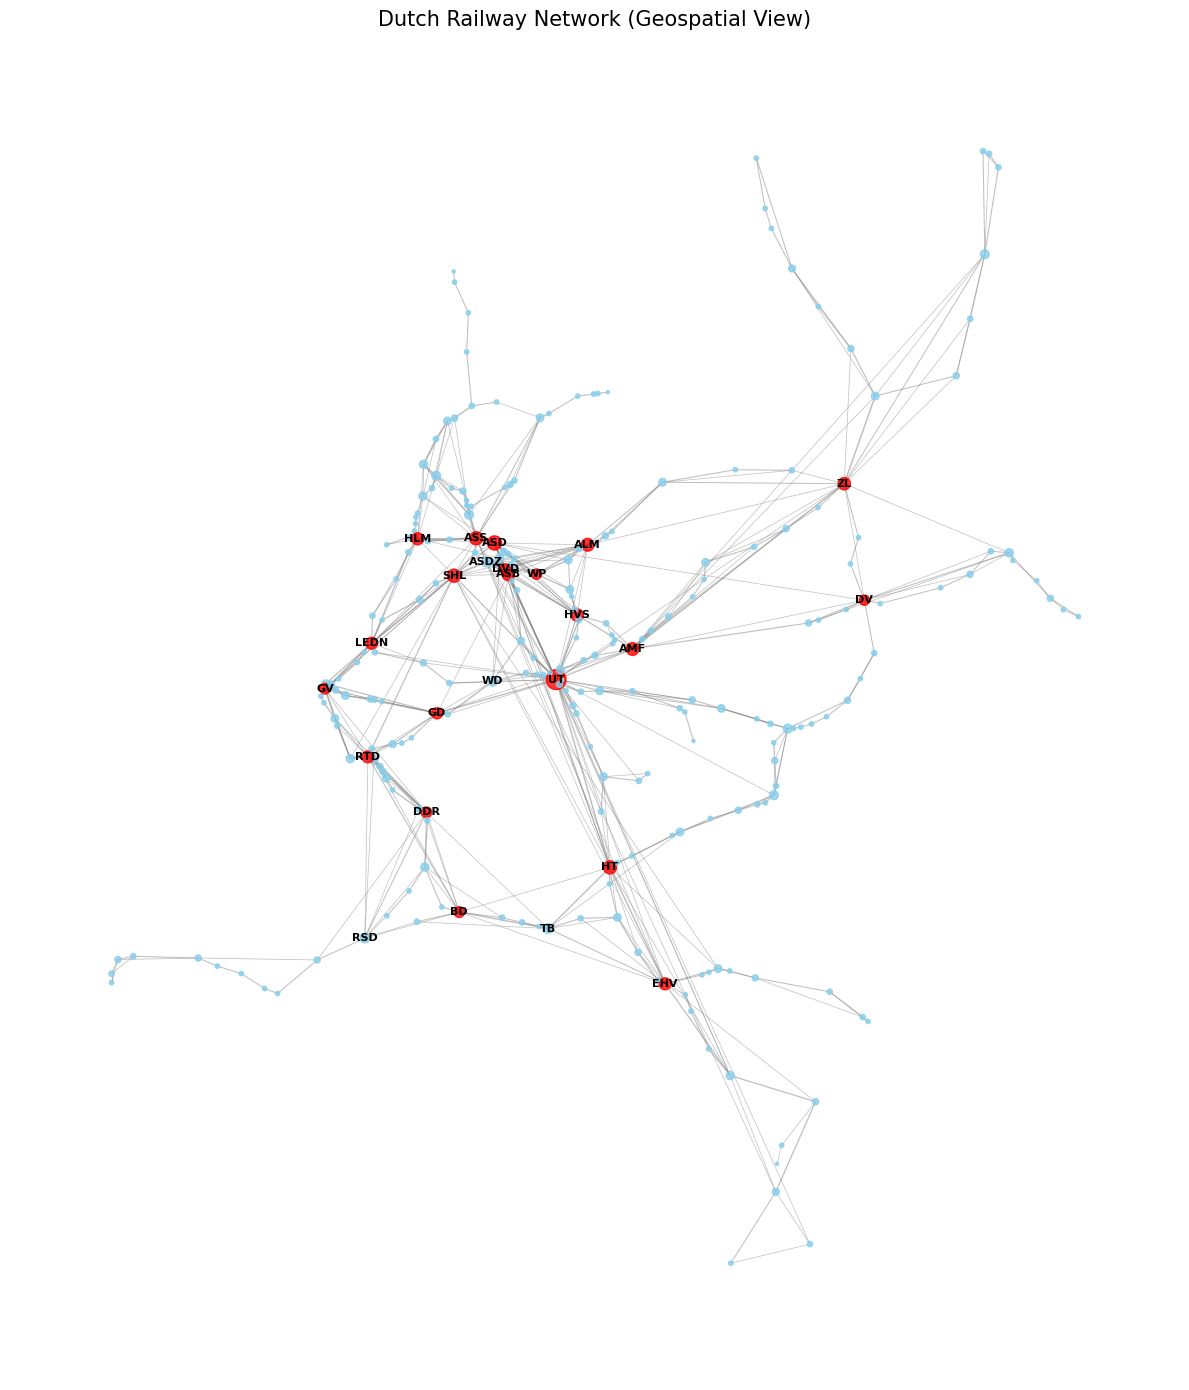

In [7]:
# 3. Build the Graph
G = nx.Graph()

# Add Nodes with positions
# NetworkX expects pos as {node_id: (x, y)} -> (longitude, latitude)
node_positions = {}
for index, row in nodes_df.iterrows():
    # standard mapping: x=longitude, y=latitude
    node_positions[row['code']] = (row['geo_lng'], row['geo_lat']) 
    G.add_node(row['code'], name=row['name'])

# Add Edges
for index, row in edges_df.iterrows():
    if row['source'] in G.nodes and row['target'] in G.nodes:
        G.add_edge(row['source'], row['target'], weight=row['frequency'])

# 4. Filter Graph
# Remove nodes that didn't end up having edges (isolated stations)
# or nodes that we have edges for but NO coordinates (foreign stations)
nodes_to_draw = [n for n in G.nodes if n in node_positions and G.degree[n] > 0]
sub_G = G.subgraph(nodes_to_draw)

# 5. Plotting
plt.figure(figsize=(12, 14)) # Taller aspect ratio for NL map

# Draw Edges (Thicker lines for frequent routes)
weights = [sub_G[u][v]['weight'] for u,v in sub_G.edges()]
# Normalize weights for visual thickness (scale between 0.5 and 3)
max_w = max(weights) if weights else 1
widths = [0.5 + (w / max_w * 2.5) for w in weights]

nx.draw_networkx_edges(sub_G, pos=node_positions, width=widths, edge_color='gray', alpha=0.5)

# Draw Nodes
# Highlight major hubs (high degree) in Red, others in Blue
degrees = dict(sub_G.degree())
node_sizes = [degrees[n] * 5 for n in sub_G.nodes()] # Size based on connections
node_colors = ['red' if degrees[n] > 10 else 'skyblue' for n in sub_G.nodes()]

nx.draw_networkx_nodes(sub_G, pos=node_positions, node_size=node_sizes, node_color=node_colors, alpha=0.8)

# Labels (Only label major hubs to avoid clutter)
major_hubs = {n: n for n in sub_G.nodes() if degrees[n] > 8} # Adjust threshold as needed
text = nx.draw_networkx_labels(sub_G, pos=node_positions, labels=major_hubs, font_size=8, font_weight='bold')

# Adjust plot boundaries to fit the map
plt.title("Dutch Railway Network (Geospatial View)", fontsize=15)
plt.axis('off') # Turn off the x/y axis numbers
plt.tight_layout()
plt.show()

# TODO/ASK:
- bricked naive/xgb models (due to changed prediction objective), prob low prio fix later 

- implement simplest GNN (with MP) 

- prep full dataset into 3 seperate for seperate time series networks(, or just use one and filter through it?)


EDA
- double check monday/sunday indexing duckdb
- rewrite OLD python code (EDA over time) into duckdb ?
- create graph from all unique trajectories in the SERVICES DATASET -> requires fulldataset? currently graph with networkx but pretty slow -> revise later for GNN? https://pyg.org/ or https://www.dgl.ai/ -> look jonathan's for inspo

- add graph characteristics summary (edge, node, graph-level, connectivity), IC/sprinter, main stops, temp stops, features, classes etc...


Q: how to deal with async (gaps) in time series of the services & disruptions dataset, assumption now that NS its services covering every hour in a day (as we aggregate by hour), but even this not guaranteed (i.e. pretty sure train operation hours of NS is not 24/7) 

Q additional datasets requirement: should complementary datasets add information on either spatial or temporal level to be valid, nothing else? Or could it be backed by any research that highlights a feature to be important for all (graph) time series related datasets (or train (delay) specifically? check with ali -> if holidays dataset SHOULD include carnaval and 11/11 in the southern part, or else it is invalid? or could it be argued as universal data availability for spatial data

Q Graph construction: 
Node = stations (+ but also trains moving in between nodes? -> hetero graph?)
Edge = lines (but does not represent # of rail tracks, but instead the trajectories, is this fine?)
Graph level = train railnetwork (-> only includes utilized by NS only, as we will probably construct the rail network from the used trajectories in the services dataset?)
Master node/Context vector -> can we make a subgraph as proxy master node capturing different info than everything? Utilizing the type of stations in the stations_df

# (OLD) IGNORE ALL BELOW AND THE MODELS FOR NOW

## Imports

In [ ]:
%matplotlib inline

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
import gzip

from darts import TimeSeries
from darts.utils.statistics import check_seasonality, extract_trend_and_seasonality, stationarity_test_kpss, plot_acf, plot_residuals_analysis


folder_path = Path("downloads/data")
services_file_path = os.path.join(folder_path, "NS-services/services.parquet")
disruptions_file_path = os.path.join(folder_path, "NS-disruptions/disruptions-2019.csv")
stations_file_path = os.path.join(folder_path, "NS-stations/stations-2023-09-nl.csv")
distances_file_path = os.path.join(folder_path, "NS-tariff-distances/tariff-distances-2022-01.csv")
ns_distances_file_path = os.path.join(folder_path, "NS-tariff-distances/tariff-distances-2022-01-ns-ns-international.csv")
holidays_file_path = os.path.join(folder_path, "holidays/dutch_holidays_2019_2025.parquet")
# weather_file_path = os.path.join(folder_path, "weather/weather_merged_all.parquet")
weather_file_path = os.path.join(folder_path, "weather/ns_stations_weather_2019.parquet")

services = pd.read_parquet(services_file_path)
holidays = pd.read_parquet(holidays_file_path)
disruptions = pd.read_csv(disruptions_file_path)
stations = pd.read_csv(stations_file_path)
distances = pd.read_csv(distances_file_path)
ns_distances = pd.read_csv(ns_distances_file_path)
weather = pd.read_parquet(weather_file_path)


FileNotFoundError: [Errno 2] No such file or directory: 'downloads\\data\\NS-services/services.parquet'

In [275]:
services.head()


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,Rotterdam Centraal,None,NaN,None,2019-01-01T02:00:00+01:00,1.0,False,True,3,2
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,Delft,2019-01-01T02:12:00+01:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,Den Haag HS,2019-01-01T02:20:00+01:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,Leiden Centraal,2019-01-01T02:35:00+01:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,Schiphol Airport,2019-01-01T03:00:00+01:00,0.0,False,2019-01-01T03:02:00+01:00,0.0,False,False,3,3


In [276]:
services.describe()

,Service:RDT-ID,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Arrival delay,Stop:Departure delay
count,3.916300e+04,39163.000000,39163.000000,3.916300e+04,35459.000000,35469.000000
mean,6.262097e+06,5984.481117,0.192503,5.590201e+07,0.617220,0.657137
std,4.033942e+06,17816.215960,1.311634,3.655504e+07,2.274406,2.144581
min,7.388040e+05,123.000000,0.000000,6.220112e+06,-8.000000,-6.000000
25%,3.108209e+06,3030.000000,0.000000,2.699512e+07,0.000000,0.000000
50%,5.562391e+06,4631.000000,0.000000,4.923475e+07,0.000000,0.000000
75%,1.036809e+07,6620.000000,0.000000,9.307157e+07,0.000000,0.000000
max,1.269197e+07,703938.000000,80.000000,1.144828e+08,80.000000,80.000000


In [277]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39163 entries, 0 to 39162
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Service:RDT-ID                39163 non-null  int64  
 1   Service:Date                  39163 non-null  object 
 2   Service:Type                  39163 non-null  object 
 3   Service:Company               39163 non-null  object 
 4   Service:Train number          39163 non-null  int64  
 5   Service:Completely cancelled  39163 non-null  bool   
 6   Service:Partly cancelled      39163 non-null  bool   
 7   Service:Maximum delay         39163 non-null  int64  
 8   Stop:RDT-ID                   39163 non-null  int64  
 9   Stop:Station code             39163 non-null  object 
 10  Stop:Station name             39163 non-null  object 
 11  Stop:Arrival time             35459 non-null  object 
 12  Stop:Arrival delay            35459 non-null  float64
 13  S

Check total services date range should be 2019-01 till 2024-12

In [278]:
import pandas as pd

services['Service:Date'] = pd.to_datetime(services['Service:Date'])

min_date = services['Service:Date'].min()
max_date = services['Service:Date'].max()
duration = max_date - min_date

print(f"Start Date (min): {min_date}")
print(f"End Date (max):   {max_date}")
print(f"Total Duration:   {duration}")


Start Date (min): 2019-01-01 00:00:00
End Date (max):   2024-01-01 00:00:00
Total Duration:   1826 days 00:00:00


(TEMP) Checking subset range

In [279]:
services_2019 = services[services['Service:Date'].dt.year == 2019]

if not services_2019.empty:
    min_date = services_2019['Service:Date'].min()
    max_date = services_2019['Service:Date'].max()
    duration = max_date - min_date

    print(f"Start Date (2019): {min_date}")
    print(f"End Date (2019):   {max_date}")
    print(f"Total Duration:    {duration}")
else:
    print("No records found for the year 2019.")

Start Date (2019): 2019-01-01 00:00:00
End Date (2019):   2019-01-01 00:00:00
Total Duration:    0 days 00:00:00


In [280]:
holidays.head()

,date,holiday_name,year,day_of_week
0,2019-01-01,Nieuwjaarsdag,2019,Tuesday
1,2019-04-19,Goede Vrijdag,2019,Friday
2,2019-04-21,Eerste paasdag,2019,Sunday
3,2019-04-22,Tweede paasdag,2019,Monday
4,2019-04-27,Koningsdag,2019,Saturday


In [281]:
holidays.describe()

,date,year
count,72,72.000000
mean,2022-06-11 18:20:00,2022.013889
min,2019-01-01 00:00:00,2019.000000
25%,2020-05-31 18:00:00,2020.000000
50%,2022-05-11 12:00:00,2022.000000
75%,2024-03-31 06:00:00,2024.000000
max,2025-12-26 00:00:00,2025.000000
std,NaN,2.031395


In [282]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          72 non-null     datetime64[ns]
 1   holiday_name  72 non-null     object        
 2   year          72 non-null     int32         
 3   day_of_week   72 non-null     object        
dtypes: datetime64[ns](1), int32(1), object(2)
memory usage: 2.1+ KB


In [283]:
disruptions.head()

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,25236,Utrecht-'s-Hertogenbosch,'s-Hertogenbosch - Utrecht Centraal,151,"Geldermalsen,'s-Hertogenbosch,Zaltbommel","GDM, HT, ZBM",defecte bovenleiding,damaged overhead wires,defecte bovenleiding,damaged overhead wires,infrastructure,2019-01-01 06:32:16,2019-01-01 06:33:31,1.0
1,25237,Almere-Lelystad; Almere-Lelystad; Hoofddorp-Sc...,"Almere Oostvaarders - Utrecht Centraal, Amster...","144,145,149","Almere Oostvaarders,Lelystad Centrum","ALMO, LLS",vandalisme,vandalism,vandalisme,vandalism,external,2019-01-01 07:12:00,2019-01-01 09:53:48,162.0
2,25238,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Ermelo,Harderwijk,Putten","EML, HD, PT",seinstoring,signal failure,seinstoring,signal failure,infrastructure,2019-01-01 08:26:58,2019-01-01 08:44:01,17.0
3,25239,Utrecht-'s-Hertogenbosch; Utrecht-Tiel,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Culemborg,Geldermalsen,Houten Castellum","CL, GDM, HTNC",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,2019-01-01 08:36:00,2019-01-01 09:09:43,34.0
4,25240,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst,Amer...","AMF, AMFS, AVAT, EML, HD, HDE, NKK, NS, PT, WZ...",herstelwerkzaamheden,repair works,herstelwerkzaamheden,repair works,engineering work,2019-01-01 09:45:48,2019-01-01 12:47:54,182.0


In [284]:
disruptions.describe()

,rdt_id,duration_minutes
count,5940.000000,5937.000000
mean,28205.500000,96.943069
std,1714.874631,297.367167
min,25236.000000,0.000000
25%,26720.750000,12.000000
50%,28205.500000,40.000000
75%,29690.250000,113.000000
max,31175.000000,17011.000000


In [285]:
disruptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5940 entries, 0 to 5939
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rdt_id                5940 non-null   int64  
 1   ns_lines              5940 non-null   object 
 2   rdt_lines             5936 non-null   object 
 3   rdt_lines_id          5936 non-null   object 
 4   rdt_station_names     5939 non-null   object 
 5   rdt_station_codes     5939 non-null   object 
 6   cause_nl              5940 non-null   object 
 7   cause_en              5940 non-null   object 
 8   statistical_cause_nl  5940 non-null   object 
 9   statistical_cause_en  5940 non-null   object 
 10  cause_group           5940 non-null   object 
 11  start_time            5940 non-null   object 
 12  end_time              5937 non-null   object 
 13  duration_minutes      5937 non-null   float64
dtypes: float64(1), int64(1), object(12)
memory usage: 649.8+ KB


from disruptions we could use start_time as boolean one hot encoding to indicate a MAJOR disruption has caused the delay

if needed categorize cause_en or utilize rdt's cause_group?

In [286]:
stations.head()

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611
3,51,ATN,8400045,Aalten,Aalten,Aalten,aalten,NL,stoptreinstation,51.921327,6.578627
4,5,AC,8400047,Abcoude,Abcoude,Abcoude,abcoude,NL,stoptreinstation,52.278500,4.977000


In [287]:
stations.describe()

,id,uic,geo_lat,geo_lng
count,397.000000,3.970000e+02,397.000000,397.000000
mean,315.503778,8.400380e+06,52.160612,5.524714
std,193.894114,2.047490e+02,0.602023,0.768896
min,5.000000,8.400045e+06,50.771946,3.595278
25%,157.000000,8.400200e+06,51.863154,4.878056
50%,304.000000,8.400362e+06,52.145279,5.573889
75%,456.000000,8.400553e+06,52.458611,6.057500
max,820.000000,8.400752e+06,53.458419,7.199370


In [288]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           397 non-null    int64  
 1   code         396 non-null    object 
 2   uic          397 non-null    int64  
 3   name_short   397 non-null    object 
 4   name_medium  397 non-null    object 
 5   name_long    397 non-null    object 
 6   slug         397 non-null    object 
 7   country      397 non-null    object 
 8   type         397 non-null    object 
 9   geo_lat      397 non-null    float64
 10  geo_lng      397 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 34.2+ KB


In [289]:
distances.head()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
0,AC,XXX,82,83,85,90,71,188,32,38,...,116,106,106,63,62,96,114,42,89,28
1,AH,82,XXX,1,3,8,77,153,98,104,...,81,120,29,106,105,14,128,123,107,109
2,AHP,83,1,XXX,2,9,78,152,99,105,...,80,121,28,107,106,13,129,124,108,110
3,AHPR,85,3,2,XXX,11,80,150,101,107,...,78,123,26,109,108,15,131,126,110,112
4,AHZ,90,8,9,11,XXX,69,161,106,112,...,89,112,37,114,113,22,120,131,99,117


In [290]:
distances.describe()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
count,398,399,399,399,399,399,399,399,399,399,...,399,399,399,399,399,399,399,399,399,399
unique,398,194,178,177,172,179,185,196,181,178,...,165,223,168,207,203,179,222,213,210,209
top,ZZS,42,119,90,122,99,80,181,53,59,...,127,138,129,72,65,103,122,75,98,136
freq,1,7,7,8,7,8,6,6,6,6,...,7,5,7,7,6,8,5,5,6,6


In [291]:
distances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Columns: 400 entries, Station to ZZS
dtypes: object(400)
memory usage: 1.2+ MB


In [292]:
ns_distances.head()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
0,AC,XXX,82,83,85,90,?,188,32,38,...,?,106,111,63,62,96,114,42,89,28
1,AH,82,XXX,1,3,8,?,153,107,113,...,?,120,29,106,105,14,128,124,132,110
2,AHP,83,1,XXX,2,9,?,152,108,114,...,?,121,28,107,106,13,129,125,133,111
3,AHPR,85,3,2,XXX,11,?,150,110,116,...,?,123,26,109,108,15,131,127,135,113
4,AHZ,90,8,9,11,XXX,?,161,115,121,...,?,112,37,114,113,22,120,132,129,118


In [293]:
ns_distances.describe()

,Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM,ALMB,...,ZLSH,ZLW,ZP,ZTM,ZTMO,ZV,ZVB,ZVT,ZWD,ZZS
count,398,399,399,399,399,399,399,399,399,399,...,399,399,399,399,399,399,399,399,399,399
unique,398,143,136,136,144,135,2,163,153,145,...,2,152,143,157,151,136,151,160,154,163
top,ZZS,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
freq,1,135,135,135,135,135,398,135,135,135,...,398,135,135,135,135,135,135,135,135,135


In [294]:
ns_distances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Columns: 400 entries, Station to ZZS
dtypes: object(400)
memory usage: 1.2+ MB


In [295]:
weather.head()

,time,station_code,station_name,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,2019-01-01 00:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.337,0.0,0.0,0.0,17.072504,30.599998,7.937
1,2019-01-01 01:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.287,0.0,0.0,0.0,18.204042,32.399998,7.637
2,2019-01-01 02:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.387,0.0,0.0,0.0,18.792551,33.480000,7.487
3,2019-01-01 03:00:00+00:00,HT,Den Bosch,51.69048,5.29362,6.937,0.0,0.0,0.0,18.792551,33.480000,7.237
4,2019-01-01 04:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.037,0.0,0.0,0.0,19.829433,35.279999,7.137


In [296]:
weather.describe()

,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
count,19056.000000,19056.000000,19056.000000,19056.000000,19056.0,19056.0,19056.000000,19056.000000,19056.000000
mean,52.160612,5.524714,6.289156,0.011361,0.0,0.0,21.111765,39.479488,6.347823
std,0.601280,0.767948,1.655974,0.041597,0.0,0.0,7.127416,12.428456,1.186811
min,50.771946,3.595278,-1.737000,0.000000,0.0,0.0,4.802999,10.440001,1.463000
25%,51.863154,4.878056,5.471875,0.000000,0.0,0.0,16.870138,32.760002,5.587000
50%,52.145279,5.573889,6.387000,0.000000,0.0,0.0,21.188072,39.599998,6.387000
75%,52.458611,6.057500,7.448500,0.000000,0.0,0.0,25.148520,46.439999,7.363000
max,53.458419,7.199370,9.730500,0.400000,0.0,0.0,50.816135,88.919998,8.493500


In [297]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19056 entries, 0 to 19055
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   time                       19056 non-null  datetime64[ns, UTC]
 1   station_code               19008 non-null  object             
 2   station_name               19056 non-null  object             
 3   latitude                   19056 non-null  float64            
 4   longitude                  19056 non-null  float64            
 5   temperature_2m             19056 non-null  float32            
 6   rain                       19056 non-null  float32            
 7   snowfall                   19056 non-null  float32            
 8   snow_depth                 19056 non-null  float32            
 9   wind_speed_10m             19056 non-null  float32            
 10  wind_gusts_10m             19056 non-null  float32            
 11  so

weather sanity check, lgtm 

In [298]:
len(weather['station_name'].unique())

397

(TEMP) preprocess test for xgb/naive -> for now aggregated timeseries + filled, check jonathan/existing papers (ETA google)

In [299]:
services.tail()

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
39158,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318424,HNK,Hoorn Kersenboogerd,2024-01-01T15:03:00+01:00,0.0,False,2024-01-01T15:03:00+01:00,0.0,False,False,2,2
39159,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318425,HKS,Hoogkarspel,2024-01-01T15:10:00+01:00,0.0,False,2024-01-01T15:10:00+01:00,0.0,False,False,2,2
39160,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318426,BKG,Bovenkarspel-Grootebroek,2024-01-01T15:15:00+01:00,0.0,False,2024-01-01T15:17:00+01:00,0.0,False,False,1,1
39161,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318427,BKF,Bovenkarspel Flora,2024-01-01T15:19:00+01:00,0.0,False,2024-01-01T15:19:00+01:00,0.0,False,False,1,1
39162,12691967,2024-01-01,Intercity,NS,2944,False,False,0,114318428,EKZ,Enkhuizen,2024-01-01T15:23:00+01:00,0.0,False,None,NaN,None,False,1,1


Sorting arrival time

In [300]:
# Ensure datetime with UTC
services["Stop:Arrival time"] = pd.to_datetime(services["Stop:Arrival time"], utc=True)

# Sort ascending
services = services.sort_values("Stop:Arrival time").reset_index(drop=True)

# RFC 3339 formatted column
services["Sorted Stop: Arrival time"] = (
    services["Stop:Arrival time"]
    .dt.strftime("%Y-%m-%dT%H:%M:%S%z")
    .str.replace(r'(\+|\-)(\d{2})(\d{2})$', r'\1\2:\3', regex=True)
)

services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01 01:12:00+00:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01 01:20:00+00:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01 01:34:00+00:00,0.0,False,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01 01:35:00+00:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01 01:44:00+00:00,1.0,False,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39158,12691959,2024-01-01,Intercity,NS,3642,False,False,8,114318316,RSD,...,NaT,NaN,None,2024-01-01T11:57:00+01:00,0.0,False,False,3a,3a,NaN
39159,12691961,2024-01-01,Sprinter,NS,7341,False,False,1,114318337,BKL,...,NaT,NaN,None,2024-01-01T11:58:00+01:00,0.0,False,False,3,3,NaN
39160,12691962,2024-01-01,Sprinter,NS,6640,False,False,1,114318348,DDR,...,NaT,NaN,None,2024-01-01T11:58:00+01:00,0.0,False,False,4b,4b,NaN
39161,12691964,2024-01-01,Sprinter,NS,6040,False,False,2,114318381,HT,...,NaT,NaN,None,2024-01-01T11:59:00+01:00,0.0,False,False,4a,4a,NaN


In [301]:
services.isna().sum()

Service:RDT-ID                     0
Service:Date                       0
Service:Type                       0
Service:Company                    0
Service:Train number               0
Service:Completely cancelled       0
Service:Partly cancelled           0
Service:Maximum delay              0
Stop:RDT-ID                        0
Stop:Station code                  0
Stop:Station name                  0
Stop:Arrival time               3704
Stop:Arrival delay              3704
Stop:Arrival cancelled          3704
Stop:Departure time             3694
Stop:Departure delay            3694
Stop:Departure cancelled        3694
Stop:Platform change               0
Stop:Planned platform            813
Stop:Actual platform             813
Sorted Stop: Arrival time       3704
dtype: int64

In [ ]:
services = services.dropna(subset=["Stop:Arrival time"]).reset_index(drop=True)

relevant_cols = ['Service:RDT-ID', 'Service:Train number', 'Stop:RDT-ID', 
 'Service:Date', 
#  'Service:Completely cancelled', 'Service:Partly cancelled', 
#  'Stop:Arrival cancelled',
 'Stop:Arrival delay', 'Stop:Arrival time', 
 'Sorted Stop: Arrival time']

In [303]:
services['Service:RDT-ID'].nunique()

3704

In [304]:
stations.head()

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611
3,51,ATN,8400045,Aalten,Aalten,Aalten,aalten,NL,stoptreinstation,51.921327,6.578627
4,5,AC,8400047,Abcoude,Abcoude,Abcoude,abcoude,NL,stoptreinstation,52.278500,4.977000


In [ ]:
#  (TEMP) 2019 only 1 day of 1 year only due to timeseries gap in subset
services = services[services['Service:Date'].dt.year == 2019].reset_index(drop=True)
services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01 01:12:00+00:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01 01:20:00+00:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01 01:34:00+00:00,0.0,False,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01 01:35:00+00:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01 01:44:00+00:00,1.0,False,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,2019-01-01 13:07:00+00:00,0.0,False,2019-01-01T14:08:00+01:00,0.0,False,False,2,2,2019-01-01T13:07:00+00:00
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,2019-01-01 13:11:00+00:00,0.0,False,None,NaN,None,False,5,5,2019-01-01T13:11:00+00:00
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,2019-01-01 13:13:00+00:00,0.0,False,2019-01-01T14:16:00+01:00,0.0,False,False,1,1,2019-01-01T13:13:00+00:00
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,2019-01-01 13:18:00+00:00,0.0,False,2019-01-01T14:18:00+01:00,0.0,False,False,1,1,2019-01-01T13:18:00+00:00


In [306]:
# Extract time bins
services['hour'] = services['Stop:Arrival time'].dt.hour
services['minute'] = services['Stop:Arrival time'].dt.minute

# quarter bins maybe for better precision? -> but async ts risk
services['quarter_hour_bin'] = (services['Stop:Arrival time'].dt.minute // 15) * 15
services

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,Sorted Stop: Arrival time,hour,minute,quarter_hour_bin
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,2019-01-01T01:12:00+00:00,1,12,0
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,2019-01-01T01:20:00+00:00,1,20,15
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,2019-01-01T02:34:00+01:00,0.0,False,False,6,6,2019-01-01T01:34:00+00:00,1,34,30
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,2019-01-01T01:35:00+00:00,1,35,30
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a,2019-01-01T01:44:00+00:00,1,44,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,2019-01-01T14:08:00+01:00,0.0,False,False,2,2,2019-01-01T13:07:00+00:00,13,7,0
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,None,NaN,None,False,5,5,2019-01-01T13:11:00+00:00,13,11,0
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,2019-01-01T14:16:00+01:00,0.0,False,False,1,1,2019-01-01T13:13:00+00:00,13,13,0
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,2019-01-01T14:18:00+01:00,0.0,False,False,1,1,2019-01-01T13:18:00+00:00,13,18,15


As service:date in services is the date scheduled arrival (delays do not affect it); we will use the start time of the disruption to determine on which date the disruption happened

In [308]:
disruptions['disruption_date'] = pd.to_datetime(disruptions['start_time']).dt.date
disruptions

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,disruption_date
0,25236,Utrecht-'s-Hertogenbosch,'s-Hertogenbosch - Utrecht Centraal,151,"Geldermalsen,'s-Hertogenbosch,Zaltbommel","GDM, HT, ZBM",defecte bovenleiding,damaged overhead wires,defecte bovenleiding,damaged overhead wires,infrastructure,2019-01-01 06:32:16,2019-01-01 06:33:31,1.0,2019-01-01
1,25237,Almere-Lelystad; Almere-Lelystad; Hoofddorp-Sc...,"Almere Oostvaarders - Utrecht Centraal, Amster...","144,145,149","Almere Oostvaarders,Lelystad Centrum","ALMO, LLS",vandalisme,vandalism,vandalisme,vandalism,external,2019-01-01 07:12:00,2019-01-01 09:53:48,162.0,2019-01-01
2,25238,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Ermelo,Harderwijk,Putten","EML, HD, PT",seinstoring,signal failure,seinstoring,signal failure,infrastructure,2019-01-01 08:26:58,2019-01-01 08:44:01,17.0,2019-01-01
3,25239,Utrecht-'s-Hertogenbosch; Utrecht-Tiel,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Culemborg,Geldermalsen,Houten Castellum","CL, GDM, HTNC",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,2019-01-01 08:36:00,2019-01-01 09:09:43,34.0,2019-01-01
4,25240,Amersfoort-Zwolle,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst,Amer...","AMF, AMFS, AVAT, EML, HD, HDE, NKK, NS, PT, WZ...",herstelwerkzaamheden,repair works,herstelwerkzaamheden,repair works,engineering work,2019-01-01 09:45:48,2019-01-01 12:47:54,182.0,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,31171,Breda-'s-Hertogenbosch,"'s-Hertogenbosch - Tilburg, Breda - Tilburg","68,69","Breda,Gilze-Rijen,'s-Hertogenbosch,Tilburg,Til...","BD, GZ, HT, TB, TBR, TBU",wisselstoring,points failure,wisselstoring,points failure,infrastructure,2019-12-31 08:07:52,2019-12-31 10:30:12,142.0,2019-12-31
5936,31172,Amersfoort-Deventer,Amersfoort - Apeldoorn,50,"Amersfoort Centraal,Apeldoorn","AMF, APD",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 08:33:02,2019-12-31 09:49:44,77.0,2019-12-31
5937,31173,Utrecht-Amersfoort,Amersfoort - Utrecht Centraal,134,"Amersfoort Centraal,Bilthoven,Den Dolder,Utrec...","AMF, BHV, DLD, UT, UTO",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 08:36:50,2019-12-31 10:29:48,113.0,2019-12-31
5938,31174,Amersfoort-Deventer,Amersfoort - Apeldoorn,50,"Amersfoort Centraal,Apeldoorn","AMF, APD",aanrijding,collision,aanrijding,collision,accidents,2019-12-31 09:12:56,2019-12-31 12:02:55,170.0,2019-12-31


In [309]:
disruptions['cause_nl'].value_counts()

cause_nl
defecte trein                   2314
gestrande trein                  531
seinstoring                      434
wisselstoring                    340
aanrijding met een persoon       316
                                ... 
de bouw van een tunnel             1
de inzet van ander materieel       1
rijp aan de bovenleiding           1
te grote vertraging                1
acties in het buitenland           1
Name: count, Length: 70, dtype: int64

In [310]:
disruptions['cause_group'].value_counts()

cause_group
rolling stock       2967
infrastructure      1383
accidents            588
external             506
logistical           218
engineering work     175
weather               61
unknown               25
staff                 17
Name: count, dtype: int64

In [311]:
weather['date'] = pd.to_datetime(weather['time']).dt.date
weather['hour'] = pd.to_datetime(weather['time']).dt.hour
weather

,time,station_code,station_name,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,date,hour
0,2019-01-01 00:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.337,0.0,0.0,0.0,17.072504,30.599998,7.937,2019-01-01,0
1,2019-01-01 01:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.287,0.0,0.0,0.0,18.204042,32.399998,7.637,2019-01-01,1
2,2019-01-01 02:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.387,0.0,0.0,0.0,18.792551,33.480000,7.487,2019-01-01,2
3,2019-01-01 03:00:00+00:00,HT,Den Bosch,51.69048,5.29362,6.937,0.0,0.0,0.0,18.792551,33.480000,7.237,2019-01-01,3
4,2019-01-01 04:00:00+00:00,HT,Den Bosch,51.69048,5.29362,7.037,0.0,0.0,0.0,19.829433,35.279999,7.137,2019-01-01,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19051,2019-01-02 19:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,3.550,0.0,0.0,0.0,10.799999,18.000000,4.600,2019-01-02,19
19052,2019-01-02 20:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.200,0.0,0.0,0.0,9.826088,19.440001,4.650,2019-01-02,20
19053,2019-01-02 21:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.000,0.0,0.0,0.0,8.942214,16.919998,4.700,2019-01-02,21
19054,2019-01-02 22:00:00+00:00,ZLSH,Stadshagen,52.52764,6.05146,4.250,0.0,0.0,0.0,10.440000,17.280001,4.750,2019-01-02,22


## Merging Datasets

### Missing values

In [312]:
print(f'Missing values in services : {services.isna().sum()}')
print(f'Missing values in holidays: {holidays.isna().sum()}')
print(f'Missing values in disruptions : {disruptions.isna().sum()}')
print(f'Missing values in stations : {stations.isna().sum()}')
print(f'Missing values in distances: {distances.isna().sum()}')
print(f'Missing values in ns_distances: {ns_distances.isna().sum()}')
print(f'Missing values in weather: {weather.isna().sum()}')

Missing values in services : Service:RDT-ID                    0
Service:Date                      0
Service:Type                      0
Service:Company                   0
Service:Train number              0
Service:Completely cancelled      0
Service:Partly cancelled          0
Service:Maximum delay             0
Stop:RDT-ID                       0
Stop:Station code                 0
Stop:Station name                 0
Stop:Arrival time                 0
Stop:Arrival delay                0
Stop:Arrival cancelled            0
Stop:Departure time             702
Stop:Departure delay            702
Stop:Departure cancelled        702
Stop:Platform change              0
Stop:Planned platform             0
Stop:Actual platform              0
Sorted Stop: Arrival time         0
hour                              0
minute                            0
quarter_hour_bin                  0
dtype: int64
Missing values in holidays: date            0
holiday_name    0
year            0
day_of_week 

### Merging all 3 datasets ns operation (services, stations, disruptions), weather and holiday dataset

In [313]:
service_with_stations_data = pd.merge(services, stations, left_on=['Stop:Station code'], right_on=['code'], how='left')


In [314]:
service_with_stations_data.head()
service_with_stations_data

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,DT,8400170.0,Delft,Delft,Delft,delft,NL,knooppuntIntercitystation,52.006668,4.356389
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,GV,8400280.0,Dn Haag HS,Den Haag HS,Den Haag HS,den-haag-hs,NL,knooppuntIntercitystation,52.069721,4.322500
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,ASB,8400074.0,Bijlmer A,Bijlmer ArenA,Amsterdam Bijlmer ArenA,amsterdam-bijlmer-arena,NL,knooppuntStoptreinstation,52.312222,4.946944
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,LEDN,8400390.0,Leiden C,Leiden C.,Leiden Centraal,leiden-centraal,NL,knooppuntIntercitystation,52.166111,4.481667
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,ASD,8400058.0,Amsterdm C,Amsterdam C.,Amsterdam Centraal,amsterdam-centraal,NL,megastation,52.378887,4.900278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,HKS,8400334.0,Hoogkrspl,Hoogkarspel,Hoogkarspel,hoogkarspel,NL,stoptreinstation,52.690556,5.183889
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,HRL,8400307.0,Heerlen,Heerlen,Heerlen,heerlen,NL,knooppuntIntercitystation,50.890835,5.975000
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,BKG,8400127.0,Bovenk-Gr,Bovenkarspel-Gr.,Bovenkarspel-Grootebroek,bovenkarspel-grootebroek,NL,stoptreinstation,52.695000,5.237778
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,BKF,8400230.0,Bovenk Flo,Bovenkarspel Fl.,Bovenkarspel Flora,bovenkarspel-flora,NL,stoptreinstation,52.696110,5.252778


In [315]:
service_with_stations_data['hour']

0        1
1        1
2        1
3        1
4        1
        ..
6793    13
6794    13
6795    13
6796    13
6797    13
Name: hour, Length: 6798, dtype: int32

In [316]:
service_with_stations_data['Stop:Arrival delay'].isna().sum()

np.int64(0)

In [317]:
service_with_stations_data['Service:Date'] = pd.to_datetime(service_with_stations_data['Service:Date']).dt.date


ns_operation_data = pd.merge(service_with_stations_data, disruptions, left_on=['Service:RDT-ID', 'Service:Date'], right_on=['rdt_id', 'disruption_date'], how='left')
ns_operation_data

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,disruption_date
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [318]:
ns_operation_with_weather = pd.merge(ns_operation_data, weather, left_on=['Stop:Station code', 'Service:Date', 'hour'], right_on=['station_code', 'date', 'hour'], how='left')
ns_operation_with_weather

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,latitude,longitude,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,date
0,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,...,52.006668,4.356389,7.693500,0.0,0.0,0.0,18.584509,35.279999,7.743500,2019-01-01
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,...,52.069721,4.322500,7.961000,0.0,0.0,0.0,22.148045,41.399998,7.761000,2019-01-01
2,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,...,52.312222,4.946944,8.059000,0.0,0.0,0.0,21.434364,37.439999,7.809000,2019-01-01
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,...,52.166111,4.481667,8.267500,0.0,0.0,0.0,24.967499,43.919998,7.817500,2019-01-01
4,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,...,52.378887,4.900278,8.172000,0.0,0.0,0.0,22.007162,39.239998,7.872000,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,NS,3940,False,False,0,6236738,HKS,...,52.690556,5.183889,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,2019-01-01
6794,739798,2019-01-01,Intercity,NS,3941,False,False,0,6237096,HRL,...,50.890835,5.975000,6.325500,0.2,0.0,0.0,19.469976,39.239998,6.375500,2019-01-01
6795,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237025,BKG,...,52.695000,5.237778,8.037001,0.0,0.0,0.0,30.472675,53.279999,8.287001,2019-01-01
6796,739825,2019-01-01,Intercity,NS,3940,False,False,0,6237183,BKF,...,52.696110,5.252778,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,2019-01-01


In [319]:
holidays

,date,holiday_name,year,day_of_week
0,2019-01-01,Nieuwjaarsdag,2019,Tuesday
1,2019-04-19,Goede Vrijdag,2019,Friday
2,2019-04-21,Eerste paasdag,2019,Sunday
3,2019-04-22,Tweede paasdag,2019,Monday
4,2019-04-27,Koningsdag,2019,Saturday
...,...,...,...,...
67,2025-05-29,Hemelvaartsdag,2025,Thursday
68,2025-06-08,Eerste Pinksterdag,2025,Sunday
69,2025-06-09,Tweede Pinksterdag,2025,Monday
70,2025-12-25,Eerste Kerstdag,2025,Thursday


In [320]:
# # Convert the 'Service:Date' column to datetime objects
# ns_operation_with_weather['Service:Date'] = pd.to_datetime(ns_operation_with_weather['Service:Date'])

# full_merged_dataset = pd.merge(ns_operation_with_weather, holidays[['holiday_name']], left_on=['Service:Date'], right_on=['date_holidays'], how='left')
# full_merged_dataset.columns

# Set 'date' as the index of holidays so we can map by it
holiday_map = holidays.set_index('date')['holiday_name']

# Map the values directly into a new column
ns_operation_with_weather['holiday_name'] = ns_operation_with_weather['Service:Date'].map(holiday_map)
full_merged_dataset = ns_operation_with_weather
full_merged_dataset.columns

Index(['Service:RDT-ID', 'Service:Date', 'Service:Type', 'Service:Company',
       'Service:Train number', 'Service:Completely cancelled',
       'Service:Partly cancelled', 'Service:Maximum delay', 'Stop:RDT-ID',
       'Stop:Station code', 'Stop:Station name', 'Stop:Arrival time',
       'Stop:Arrival delay', 'Stop:Arrival cancelled', 'Stop:Departure time',
       'Stop:Departure delay', 'Stop:Departure cancelled',
       'Stop:Platform change', 'Stop:Planned platform', 'Stop:Actual platform',
       'Sorted Stop: Arrival time', 'hour', 'minute', 'quarter_hour_bin', 'id',
       'code', 'uic', 'name_short', 'name_medium', 'name_long', 'slug',
       'country', 'type', 'geo_lat', 'geo_lng', 'rdt_id', 'ns_lines',
       'rdt_lines', 'rdt_lines_id', 'rdt_station_names', 'rdt_station_codes',
       'cause_nl', 'cause_en', 'statistical_cause_nl', 'statistical_cause_en',
       'cause_group', 'start_time', 'end_time', 'duration_minutes',
       'disruption_date', 'time', 'station_code', 's

In [321]:
check = full_merged_dataset[(full_merged_dataset['Service:RDT-ID'] == 738804)]
check = check[['id', 'code', 'uic']]
check

,id,code,uic
0,144.0,DT,8400170.0
1,213.0,GV,8400280.0
3,308.0,LEDN,8400390.0
5,428.0,SHL,8400561.0
8,43.0,ASD,8400058.0
15,467.0,UT,8400621.0


In [322]:
relevant_cols = [
'Service:RDT-ID', 'Service:Date', 'Service:Type',
# 'Service:Company',
'Service:Train number',
# 'Service:Completely cancelled', 'Service:Partly cancelled', 
'Service:Maximum delay', 'Stop:RDT-ID',
'Stop:Station code', 'Stop:Station name', 
'Stop:Arrival time', 'Stop:Arrival delay', 
# 'Stop:Arrival cancelled', 
'Stop:Departure time', 'Stop:Departure delay', 'Stop:Departure cancelled',
'Stop:Platform change',
# 'Stop:Planned platform', 'Stop:Actual platform',
'Sorted Stop: Arrival time', 'hour', 'minute', 'quarter_hour_bin',
'id', 
#'code', 'uic', 
#'name_short', 'name_medium', 
'name_long', 'slug',
# 'country', 
'type',
'geo_lat', 'geo_lng',
#'rdt_id', 'ns_lines',
'rdt_lines', 'rdt_lines_id', 'rdt_station_names', 'rdt_station_codes',
# 'cause_nl', 
'cause_en', 
# 'statistical_cause_nl', 'statistical_cause_en',
'cause_group', 'start_time', 'end_time', 'duration_minutes',
'disruption_date', 'time', 
'station_code', 'station_name', 
# 'latitude', 'longitude', 
'temperature_2m', 'rain', 'snowfall', 'snow_depth',
'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
#'date'
]

In [323]:
full_merged_dataset = full_merged_dataset[relevant_cols]
full_merged_dataset

,Service:RDT-ID,Service:Date,Service:Type,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,...,time,station_code,station_name,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,738804,2019-01-01,Intercity,1410,0,6220116,DT,Delft,2019-01-01 01:12:00+00:00,0.0,...,2019-01-01 01:00:00+00:00,DT,Delft,7.693500,0.0,0.0,0.0,18.584509,35.279999,7.743500
1,738804,2019-01-01,Intercity,1410,0,6220120,GV,Den Haag HS,2019-01-01 01:20:00+00:00,1.0,...,2019-01-01 01:00:00+00:00,GV,Dn Haag HS,7.961000,0.0,0.0,0.0,22.148045,41.399998,7.761000
2,738805,2019-01-01,Intercity,1409,0,6220122,ASB,Amsterdam Bijlmer ArenA,2019-01-01 01:34:00+00:00,0.0,...,2019-01-01 01:00:00+00:00,ASB,Bijlmer A,8.059000,0.0,0.0,0.0,21.434364,37.439999,7.809000
3,738804,2019-01-01,Intercity,1410,0,6220124,LEDN,Leiden Centraal,2019-01-01 01:35:00+00:00,0.0,...,2019-01-01 01:00:00+00:00,LEDN,Leiden C,8.267500,0.0,0.0,0.0,24.967499,43.919998,7.817500
4,738805,2019-01-01,Intercity,1409,0,6220125,ASD,Amsterdam Centraal,2019-01-01 01:44:00+00:00,1.0,...,2019-01-01 01:00:00+00:00,ASD,Amsterdm C,8.172000,0.0,0.0,0.0,22.007162,39.239998,7.872000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,3940,0,6236738,HKS,Hoogkarspel,2019-01-01 13:07:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,HKS,Hoogkrspl,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500
6794,739798,2019-01-01,Intercity,3941,0,6237096,HRL,Heerlen,2019-01-01 13:11:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,HRL,Heerlen,6.325500,0.2,0.0,0.0,19.469976,39.239998,6.375500
6795,739825,2019-01-01,Intercity,3940,0,6237025,BKG,Bovenkarspel-Grootebroek,2019-01-01 13:13:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,BKG,Bovenk-Gr,8.037001,0.0,0.0,0.0,30.472675,53.279999,8.287001
6796,739825,2019-01-01,Intercity,3940,0,6237183,BKF,Bovenkarspel Flora,2019-01-01 13:18:00+00:00,0.0,...,2019-01-01 13:00:00+00:00,BKF,Bovenk Flo,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500


In [324]:
full_merged_dataset['Arrival Delay'] = full_merged_dataset['Stop:Arrival delay'].astype(int)

C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\1880596689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_merged_dataset['Arrival Delay'] = full_merged_dataset['Stop:Arrival delay'].astype(int)


In [325]:
full_merged_dataset

,Service:RDT-ID,Service:Date,Service:Type,Service:Train number,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,...,station_code,station_name,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm,Arrival Delay
0,738804,2019-01-01,Intercity,1410,0,6220116,DT,Delft,2019-01-01 01:12:00+00:00,0.0,...,DT,Delft,7.693500,0.0,0.0,0.0,18.584509,35.279999,7.743500,0
1,738804,2019-01-01,Intercity,1410,0,6220120,GV,Den Haag HS,2019-01-01 01:20:00+00:00,1.0,...,GV,Dn Haag HS,7.961000,0.0,0.0,0.0,22.148045,41.399998,7.761000,1
2,738805,2019-01-01,Intercity,1409,0,6220122,ASB,Amsterdam Bijlmer ArenA,2019-01-01 01:34:00+00:00,0.0,...,ASB,Bijlmer A,8.059000,0.0,0.0,0.0,21.434364,37.439999,7.809000,0
3,738804,2019-01-01,Intercity,1410,0,6220124,LEDN,Leiden Centraal,2019-01-01 01:35:00+00:00,0.0,...,LEDN,Leiden C,8.267500,0.0,0.0,0.0,24.967499,43.919998,7.817500,0
4,738805,2019-01-01,Intercity,1409,0,6220125,ASD,Amsterdam Centraal,2019-01-01 01:44:00+00:00,1.0,...,ASD,Amsterdm C,8.172000,0.0,0.0,0.0,22.007162,39.239998,7.872000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,739825,2019-01-01,Intercity,3940,0,6236738,HKS,Hoogkarspel,2019-01-01 13:07:00+00:00,0.0,...,HKS,Hoogkrspl,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,0
6794,739798,2019-01-01,Intercity,3941,0,6237096,HRL,Heerlen,2019-01-01 13:11:00+00:00,0.0,...,HRL,Heerlen,6.325500,0.2,0.0,0.0,19.469976,39.239998,6.375500,0
6795,739825,2019-01-01,Intercity,3940,0,6237025,BKG,Bovenkarspel-Grootebroek,2019-01-01 13:13:00+00:00,0.0,...,BKG,Bovenk-Gr,8.037001,0.0,0.0,0.0,30.472675,53.279999,8.287001,0
6796,739825,2019-01-01,Intercity,3940,0,6237183,BKF,Bovenkarspel Flora,2019-01-01 13:18:00+00:00,0.0,...,BKF,Bovenk Flo,8.043500,0.0,0.0,0.0,30.472675,53.279999,8.293500,0


### Add trajectories column for train at given service 
services RDT-ID (train traversing over multiple stations), sort by utilize stations connection and Stop:Station code, train only have so many lines from and to stations right? signal current trajectory it is on and where it is heading

Service:RDT-ID uid per day per service

from station X to station Y

In [326]:
# 1. Ensure the Departure Time is a datetime object so we can sort correctly
full_merged_dataset['Stop:Departure time'] = pd.to_datetime(full_merged_dataset['Stop:Departure time'])

# 2. Sort the data
# We sort by ID first, then by Time. 
# na_position='last' is CRITICAL here: The final station usually has no Departure Time 
# (because the train ends there), so we force NaNs to the bottom to ensure it's treated as the last stop.
df_sorted = full_merged_dataset.sort_values(
    by=['Service:RDT-ID', 'Stop:Departure time'], 
    na_position='last'
)

# 3. Create the GroupBy object
# We group by the unique service ID so operations happen per train
grouped = df_sorted.groupby('Service:RDT-ID')['Stop:Station name']

# 4. Create Source and Target Columns
# .transform('first') takes the first station in the sorted group and applies it to ALL rows in that group
# .transform('last') does the same for the last station
full_merged_dataset['Source_Station'] = grouped.transform('first')
full_merged_dataset['Target_Station'] = grouped.transform('last')

# 5. Create the Trajectory Column
full_merged_dataset['Trajectory'] = (
    full_merged_dataset['Source_Station'] + ' -> ' + full_merged_dataset['Target_Station']
)

# Optional: Verify the result
print(full_merged_dataset[['Service:RDT-ID', 'Stop:Station name', 'Trajectory']].head())

   Service:RDT-ID        Stop:Station name  \
0          738804                    Delft   
1          738804              Den Haag HS   
2          738805  Amsterdam Bijlmer ArenA   
3          738804          Leiden Centraal   
4          738805       Amsterdam Centraal   

                                      Trajectory  
0                      Delft -> Utrecht Centraal  
1                      Delft -> Utrecht Centraal  
2  Amsterdam Bijlmer ArenA -> Rotterdam Centraal  
3                      Delft -> Utrecht Centraal  
4  Amsterdam Bijlmer ArenA -> Rotterdam Centraal  


C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\844491184.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_merged_dataset['Stop:Departure time'] = pd.to_datetime(full_merged_dataset['Stop:Departure time'])
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\844491184.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_merged_dataset['Source_Station'] = grouped.transform('first')
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\844491184.py:21: SettingWithCopyWarning: 
A value is trying to be 

### Transforming into time series object

In [327]:
full_merged_dataset['time']

0      2019-01-01 01:00:00+00:00
1      2019-01-01 01:00:00+00:00
2      2019-01-01 01:00:00+00:00
3      2019-01-01 01:00:00+00:00
4      2019-01-01 01:00:00+00:00
                  ...           
6793   2019-01-01 13:00:00+00:00
6794   2019-01-01 13:00:00+00:00
6795   2019-01-01 13:00:00+00:00
6796   2019-01-01 13:00:00+00:00
6797   2019-01-01 13:00:00+00:00
Name: time, Length: 6798, dtype: datetime64[ns, UTC]

In [328]:
# 1. Aggregate the data to handle multiple trains per hour
# We group by Station and Time, and take the MEAN of the delay (?), i.e. we lose info about individual trains but get hourly data per station for xgboost?

# Define how to aggregate different columns, we can take the first value as they are the same for all trains incoming to that station for that hour
agg_rules = {
    'Arrival Delay': 'mean',  # Average delay
    'holiday_name': 'first',  # Keep the holiday name (it's the same for all trains that hour)
    'temperature_2m': 'first',
    'rain': 'first',
    'snowfall': 'first',
    'snow_depth': 'first',
    'wind_speed_10m': 'first',
    'wind_gusts_10m': 'first',
    'soil_temperature_0_to_7cm': 'first'
}

# Only include columns that actually exist in your dataset
existing_cols = full_merged_dataset.columns
final_rules = {k: v for k, v in agg_rules.items() if k in existing_cols}

# Perform the aggregation
df_aggregated = full_merged_dataset.groupby(['Stop:Station code', 'time']).agg(final_rules).reset_index()

# Now create the TimeSeries
all_series = TimeSeries.from_group_dataframe(
    df_aggregated, 
    time_col='time', 
    value_cols='Arrival Delay',      # The target we want to predict
    static_cols=['temperature_2m', 'rain', 'snowfall', 'snow_depth', 'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm'], # Treat weather as covariates
    group_cols='Stop:Station code',
    freq='h'
)


The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


In [329]:
df_aggregated

,Stop:Station code,time,Arrival Delay,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,AC,2019-01-01 07:00:00+00:00,0.50,8.387000,0.0,0.0,0.0,22.366402,38.519997,7.437
1,AC,2019-01-01 08:00:00+00:00,0.00,8.587001,0.1,0.0,0.0,22.668568,38.880001,7.487
2,AC,2019-01-01 09:00:00+00:00,0.00,9.137000,0.1,0.0,0.0,22.862123,39.599998,7.637
3,AC,2019-01-01 10:00:00+00:00,0.00,9.387000,0.1,0.0,0.0,19.373219,39.239998,7.787
4,AH,2019-01-01 06:00:00+00:00,1.50,7.011000,0.0,0.0,0.0,21.398056,39.959999,7.011
...,...,...,...,...,...,...,...,...,...,...
1459,ZZS,2019-01-01 07:00:00+00:00,0.50,8.700000,0.0,0.0,0.0,24.503809,42.839996,7.600
1460,ZZS,2019-01-01 08:00:00+00:00,0.25,9.150000,0.0,0.0,0.0,24.482647,42.480000,7.700
1461,ZZS,2019-01-01 09:00:00+00:00,0.00,9.550000,0.1,0.0,0.0,22.424271,43.199997,7.900
1462,ZZS,2019-01-01 10:00:00+00:00,0.00,9.400000,0.0,0.0,0.0,18.947083,38.519997,8.000


In [330]:
# Split data into Train and Test
# This takes the last 5 hours of EACH station (group) as test data
series_train = [s[:-5] for s in all_series]
series_test = [s[-5:] for s in all_series]

print(f"Number of stations (series) processed: {len(all_series)}")

Number of stations (series) processed: 242


## EDA

(placeholder) For visualization purposes and to see higher level trends, we perform the EDA on a higher level over total arrival delay instead of detailed individual service level

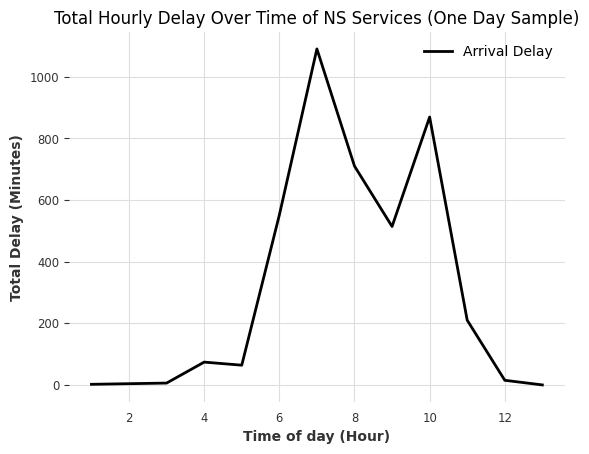

In [331]:
# Aggregate arrival delay by hour (sum of arrival delay minutes for all trains on a given hour in a day)
df_aggregated = full_merged_dataset.groupby('hour')['Arrival Delay'].sum().reset_index()

# Create a TimeSeries from the aggregated DataFrame
total_hourly_delay_one_day = TimeSeries.from_dataframe(df_aggregated, time_col='hour', value_cols='Arrival Delay')

# Plot the aggregated delay time series
total_hourly_delay_one_day.plot();
plt.title("Total Hourly Delay Over Time of NS Services (One Day Sample)")
plt.xlabel("Time of day (Hour)")
plt.ylabel("Total Delay (Minutes)")
plt.show()


We see slight upward trend (most likely due to an increasing population) and a seasonality. In addition there's a drop near the end of the year, probably due to christmas break. There is also a strange peak near mid 2015, after further investigation we concluded that this was probably caused by natural disaster i.e. flooding and tornado, which caused and hoarding of supplies including food (https://en.wikipedia.org/wiki/2015_Texas%E2%80%93Oklahoma_flood_and_tornado_outbreak)

### Seasonality

In [332]:
seasonality = check_seasonality(total_hourly_delay_one_day, max_lag=24)
seasonality

(True, np.int64(10))

Has a seasonality period of 10

### Stationary

In [333]:
stationarity_test_kpss(total_hourly_delay_one_day, nlags=10)

(np.float64(0.4175076497950632),
 np.float64(0.06960877164005896),
 10,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

p >= 0.05, we do fail to reject the null hypothesis of stationarity. This suggests that the time series is stationary at 5% significance level.

(placeholder) p < 0.05, we reject the null hypothesis of stationarity. This suggests that the time series is non-stationary, and might need to apply techniques such as differencing or transformation to make it stationary before proceeding with further time series modeling (e.g., ARIMA).

### ACF

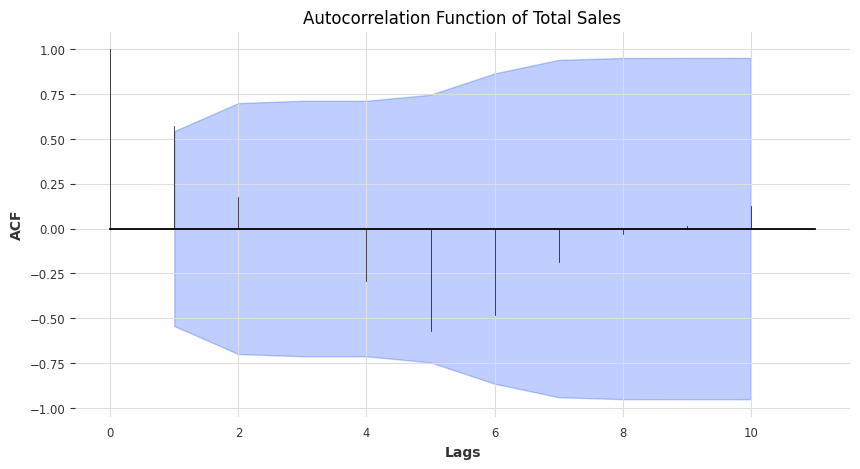

In [334]:
plot_acf(total_hourly_delay_one_day, max_lag=10)

plt.title("Autocorrelation Function of Total Sales")
plt.xlabel("Lags")
plt.ylabel("ACF")

plt.show()

Shows highest correlation at lag 5

# Models Naive & XGB
2 rows in services for departure location and arrival location

Prediction Objectives: 
- for time horizon H (hour bin) will incoming train at station X be delayed or not?
- (regression) arrival delay

We want to predict for time horizon, we have set time horizon = 1 hour, so time_col = 

We want to predict the arrival delay duration (regression) so_value = 'Stop:Arrival delay'
We want to predict per arrival station so we group by 'Stop:Station code'

Encode Categorical Variables

In [335]:
from darts.dataprocessing.transformers import StaticCovariatesTransformer

# Initialize the transformer
transformer = StaticCovariatesTransformer()

# Fit and transform the training data
series_train = transformer.fit_transform(series_train)

series_test = transformer.fit_transform(series_test)


In [344]:
from darts.models import GlobalNaiveSeasonal, RandomForest, XGBModel, LightGBMModel

forecasts = {}

seasonality_period = 10

input_chunk_length = seasonality_period * 2
output_chunk_length = seasonality_period

random_state = 8

xgb_model = XGBModel(lags=seasonality_period, random_state = random_state)
naive_model = GlobalNaiveSeasonal(input_chunk_length=input_chunk_length, output_chunk_length=output_chunk_length)

naive_model.fit(series_train)
xgb_model.fit(series_train)


naive_forecast = [naive_model.predict(5, series=ts) for ts in series_train]
xgb_forecast = [xgb_model.predict(5, series=ts) for ts in series_train]


result_naive = pd.DataFrame()
result_xgb = pd.DataFrame()


for i, ts in enumerate(series_train):
    station_id = ts.static_covariates['id']

    naive_values = np.round(naive_forecast[i].values().flatten()).astype(int)
    xgb_values = np.round(xgb_forecast[i].values().flatten()).astype(int)

    result_naive = pd.concat([
        result_naive,
        pd.DataFrame({'id': station_id, **{f"F{i+1}": val for i, val in enumerate(naive_values)}})
    ])
    result_xgb = pd.concat([
        result_xgb,
        pd.DataFrame({'id': station_id, **{f"F{i+1}": val for i, val in enumerate(xgb_values)}})
    ])


result_naive.to_csv('result_naive.csv', index=False)
result_xgb.to_csv('result_xgb.csv', index=False)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
ValueError: Specified series do not share any common times for which features can be created.


ValueError: Specified series do not share any common times for which features can be created.

In [336]:

# Keep only relevant columns
df_sorted_agg = df_sorted[['Service:RDT-ID', 'Stop:Arrival delay', 'Stop:Arrival time']]

# Function to resample each service individually
def aggregate_5min(group, service_id):
    # Set datetime index for resampling
    group = group.set_index('Stop:Arrival time')
    # Resample to 5-minute intervals and take mean
    group_resampled = group.resample('5T').mean()
    # Forward-fill missing delays
    group_resampled['Stop:Arrival delay'] = group_resampled['Stop:Arrival delay'].fillna(method='ffill')
    # Reset index to keep datetime as a column
    group_resampled = group_resampled.reset_index()
    # Add service ID back
    group_resampled['Service:RDT-ID'] = service_id
    return group_resampled

# Apply to each service
df_list = []
for service_id, group in df_sorted_agg.groupby('Service:RDT-ID'):
    df_list.append(aggregate_5min(group, service_id))

# Combine all services back into a single DataFrame
df_agg = pd.concat(df_list, ignore_index=True)

print(df_agg.head())
print(df_agg.dtypes)

C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  group_resampled = group.resample('5T').mean()
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group_resampled['Stop:Arrival delay'] = group_resampled['Stop:Arrival delay'].fillna(method='ffill')
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  group_resampled = group.resample('5T').mean()
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group_resampled['Stop:Arrival delay'] = group_resampled['Stop:A

          Stop:Arrival time  Service:RDT-ID  Stop:Arrival delay
0 2019-01-01 01:10:00+00:00          738804                 0.0
1 2019-01-01 01:15:00+00:00          738804                 0.0
2 2019-01-01 01:20:00+00:00          738804                 1.0
3 2019-01-01 01:25:00+00:00          738804                 1.0
4 2019-01-01 01:30:00+00:00          738804                 1.0
Stop:Arrival time     datetime64[ns, UTC]
Service:RDT-ID                      int64
Stop:Arrival delay                float64
dtype: object


C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  group_resampled = group.resample('5T').mean()
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group_resampled['Stop:Arrival delay'] = group_resampled['Stop:Arrival delay'].fillna(method='ffill')
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  group_resampled = group.resample('5T').mean()
C:\Users\jialo\AppData\Local\Temp\ipykernel_15288\3269846934.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group_resampled['Stop:Arrival delay'] = group_resampled['Stop:A

In [337]:
split_index = int(len(df_sorted) * 0.8)
train_df = df_agg.iloc[:split_index].reset_index(drop=True)
test_df = df_agg.iloc[split_index:].reset_index(drop=True)


In [338]:
series_train = TimeSeries.from_group_dataframe(
    train_df,
    time_col='Stop:Arrival time',
    value_cols='Stop:Arrival delay',
    group_cols='Service:RDT-ID',
    fill_missing_dates=True,  # fill gaps if any
    freq='5T'                 # explicitly tell Darts it's 5-minute intervals
)

series_test = TimeSeries.from_group_dataframe(
    test_df,
    time_col='Stop:Arrival time',
    value_cols='Stop:Arrival delay',
    group_cols='Service:RDT-ID',
    fill_missing_dates=True,  # fill gaps if any
    freq='5T'                 # explicitly tell Darts it's 5-minute intervals
)

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\darts\timeseries.py:5145: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_times = resampled_times.asfreq(freq)
c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\darts\timeseries.py:5145: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_times = resampled_times.asfreq(freq)
c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-pa

# GNN
Some graph libraries
https://pyg.org/
https://www.dgl.ai/


Look further into graph construction of existing work

IDEA (master node): can we utilize subgraphs as additional Context Vector (i.e. master nodes) utilizing the station classification (making multiple subgraphs of > major stations 'type' classification, assumption is that the graph connectivity stays the same; so given a node we could utilize the nearest neighbours of these subgraphs as additional feature/signals)

Node = stations (+ but also trains moving in between nodes? -> hetero graph)
Edge = lines (but does not represent # of rail tracks, so how to model # of lines? or just '1 shared railline')
Graph level = train railnetwork (include utilized by NS only? how? from to station data? or like jonathans official rail network (is there an alternative)?)
Master node/Context vector -> can we make a subgraph as proxy master node capturing different info than everything? maybe only large station nodes and intercity lines?

De stations in deze dataset worden gebruikt door de Rijden de Treinen website en app. De bron voor deze data is NS; de stations worden direct uit de NS API gehaald. De stationsnamen, geocoördinaten en stationcodes worden bepaald door NS.

rdt_id/id = intern RdT ID

code stationsnaam code max 8 chars, NS/prorail code

UIC code (international id station code), nl stations have 84 prefix

name_short korte station
name_medium
name_long full station name

slug = uniek small case, no space, consistent w RdT stationspage

type = Het soort station. Mogelijke waarden zijn (van groot naar klein station): megastation, knooppuntIntercitystation, intercitystation, knooppuntSneltreinstation, sneltreinstation, knooppuntStoptreinstation, stoptreinstation, facultatiefStation. De categorie knooppunt impliceert dat deze stations bedoeld zijn voor het overstappen op een andere trein. Een facultatiefStation is een station waar normaal gesproken geen treinen stoppen, behalve bij speciale gelegenheden (zoals voetbalwedstrijden).


Check the following for EDA on stations: different kind of stations
KnooppuntStation
Facultiefstation
check Knooppunt
Station coverage (i.e. which stations have the most # of trains stopping/crossing)

Check whether all stations are covered by atleast one train/service (per year?)

Filter on NL, for double check

geo_lat, latitude degree
geo_lng, longitude degree

